In [1]:
import math, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import scipy.stats as sp_stats
import scipy.special as sc
from scipy.optimize import minimize

# ── Paths ─────────────────────────────────────────────────────────────────────
CODE_DIR  = Path().resolve()
DATA_DIR  = CODE_DIR.parent.parent / "Data" / "Intraday price data" / "Rates"
PAPER_DIR = CODE_DIR.parent / "Paper" / "sections" / "5_results"
FIG_DIR   = PAPER_DIR / "figures"
TAB_DIR   = PAPER_DIR / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

# ── Constants ─────────────────────────────────────────────────────────────────
VAR_ALPHA = 0.05          # VaR / ES coverage level

ASSETS = {
    "TY": ("US Treasury",  DATA_DIR / "TY.csv"),
    "BN": ("German Bund",  DATA_DIR / "BN.csv"),
    "GL": ("UK Gilt",      DATA_DIR / "GL.csv"),
    "JB": ("Japanese JGB", DATA_DIR / "JB.csv"),
}
ORDER  = ["TY", "BN", "GL", "JB"]
LABELS = {k: v[0] for k, v in ASSETS.items()}

# ── Plot style ────────────────────────────────────────────────────────────────
C_BLUE, C_ORANGE, C_GREEN = "#2171B5", "#E6550D", "#31A354"
C_RED,  C_PURPLE, C_GRAY  = "#CB181D", "#756BB1", "#AAAAAA"
MCOLORS = {"TY": C_BLUE, "BN": C_ORANGE, "GL": "#A23B72", "JB": "#1B998B"}

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "savefig.facecolor": "white", "font.size": 10,
    "axes.labelsize": 11, "axes.titlesize": 12,
    "axes.grid": True, "grid.alpha": 0.25,
})

CRISIS = [("2008-03-01", "2009-06-01"), ("2020-02-01", "2020-06-01")]

def shade_crises(ax):
    for s, e in CRISIS:
        ax.axvspan(pd.Timestamp(s), pd.Timestamp(e), alpha=0.10, color="red")

print("Setup OK")

Setup OK


## 1. Math Utilities

In [3]:
# Numerically stable scalar transforms used for parameter constraints.

def softplus(x):
    x = float(x)
    if x > 30:  return x
    if x < -30: return math.exp(x)
    return math.log1p(math.exp(x))

def inv_softplus(y):
    y = float(y)
    if y > 30: return y
    return math.log(math.exp(y) - 1.0 + 1e-12)

def sigmoid(x):
    # Handles both scalars and arrays
    if np.ndim(x) == 0:
        x = float(x)
        z = math.exp(-abs(x))
        return 1.0 / (1.0 + z) if x >= 0 else z / (1.0 + z)
    x = np.asarray(x, float)
    return np.where(x >= 0, 1.0 / (1.0 + np.exp(-x)), np.exp(x) / (1.0 + np.exp(x)))

def softmax(logits):
    z = np.asarray(logits, float) - np.max(logits)
    ez = np.exp(z)
    return ez / ez.sum()

print("Math utilities OK")

Math utilities OK


## 2. COCOB Optimizer

Parameter-free online optimizer (Orabona & Pál, 2017).  
No learning rate to tune — adapts automatically to gradient scale.

In [5]:
def cocob_init(n, alpha=100.0):
    return {
        "alpha": alpha,
        "w":     np.zeros(n, float),   # current parameter vector
        "gs":    np.zeros(n, float),   # cumulative gradient sum
        "gns":   np.zeros(n, float),   # cumulative |gradient| sum
        "L":     np.full(n, 1e-8),     # max |gradient| seen so far
        "tw":    np.zeros(n, float),   # tilde_w (internal)
        "rwd":   np.zeros(n, float),   # reward accumulator
    }

def cocob_step(s, grad):
    grad = np.asarray(grad, float)
    L   = np.maximum(s["L"],   np.abs(grad))
    gs  = s["gs"]  + grad
    gns = s["gns"] + np.abs(grad)
    rwd = np.maximum(s["rwd"] - grad * s["tw"], 0.0)
    new_w = -gs / (L * np.maximum(gns + L, s["alpha"] * L)) * (rwd + L)
    s["w"]  += new_w - s["tw"]
    s["tw"]  = new_w
    s["gs"]  = gs;  s["gns"] = gns
    s["L"]   = L;   s["rwd"] = rwd

def cocob_get(s):           return s["w"].copy()
def cocob_set(s, params):   s["w"] = np.asarray(params, float).copy()

print("COCOB OK")

COCOB OK


## 3. Volatility Models

Each model exposes the same functional interface used by the MAOL loop:
- `init_raw(init_var)` → initial unconstrained parameter vector
- `constrain(raw)` → dict of named constrained parameters
- `forecast(params, state)` → scalar h_t
- `raw_gradient(raw, state, dL_dh)` → gradient wrt raw params
- `init_state(init_var)` / `update_state(state, h_t, rv_t)` → state management
- `statistics(params)` → dict of derived diagnostics (may be empty)

In [7]:
# ── RV-GARCH(1,1): h_t = omega + alpha*RV_{t-1} + beta*h_{t-1} ───────────────
# Constraints: omega > 0,  alpha + beta < 1  (stationarity)

def garch_init_raw(init_var):
    omega0 = inv_softplus(0.05 * max(float(init_var), 1e-12))
    logits  = np.log(np.array([0.10, 0.80, 0.10]) + 1e-12)   # alpha, beta, slack
    return np.concatenate(([omega0], logits))

def garch_constrain(raw):
    w     = softmax(raw[1:])
    scale = 1.0 - 1e-9
    return {"omega": softplus(raw[0]), "alpha": scale * w[0], "beta": scale * w[1]}

def garch_forecast(p, s):
    return p["omega"] + p["alpha"] * s["rv"] + p["beta"] * s["h"]

def garch_raw_gradient(raw, s, dL_dh):
    w  = softmax(raw[1:])
    fv = np.array([s["rv"], s["h"], 0.0])      # feature vector per logit
    gw = (1.0 - 1e-9) * dL_dh * fv
    g  = np.empty(4)
    g[0]  = dL_dh * sigmoid(raw[0])            # omega gradient
    g[1:] = w * (gw - float(np.dot(w, gw)))    # softmax Jacobian
    return g

def garch_init_state(init_var):   return {"rv": float(init_var), "h": float(init_var)}
def garch_update_state(s, h, rv): return {"rv": float(rv),       "h": float(h)}

def garch_statistics(p):
    persistence = p["alpha"] + p["beta"]
    alpha_share = p["alpha"] / max(persistence, 1e-30)
    stats = {"persistence": persistence, "alpha_share": alpha_share}
    if persistence < 1.0 - 1e-8:
        stats["long_run_vol"] = math.sqrt(p["omega"] / max(1.0 - persistence, 1e-12))
    else:
        stats["long_run_vol"] = float("nan")
    return stats


# ── HAR-RV: h_t = b0 + b_d*RV_{t-1} + b_w*mean(RV,5) + b_m*mean(RV,22) ─────
# All coefficients strictly positive via softplus; positivity guaranteed.

_HAR_W, _HAR_M = 5, 22   # weekly / monthly lags

def har_init_raw(init_var):
    iv = max(float(init_var), 1e-12)
    # Initialise in softplus-space: softplus(r) ≈ target coefficient
    # intercept = 0.05*iv, slopes = 0.45, 0.35, 0.15 (sum ≈ 0.95)
    return np.array([inv_softplus(0.05 * iv),
                     inv_softplus(0.45),
                     inv_softplus(0.35),
                     inv_softplus(0.15)])

def har_constrain(raw):
    # All coefficients strictly positive via softplus
    return {"beta0":  float(softplus(raw[0])),
            "beta_d": float(softplus(raw[1])),
            "beta_w": float(softplus(raw[2])),
            "beta_m": float(softplus(raw[3]))}

def _har_features(buf):
    return np.array([1.0, buf[0], buf[:_HAR_W].mean(), buf[:_HAR_M].mean()])

def har_forecast(p, s):
    x = _har_features(s["buf"])
    return p["beta0"]*x[0] + p["beta_d"]*x[1] + p["beta_w"]*x[2] + p["beta_m"]*x[3]

def har_raw_gradient(raw, s, dL_dh):
    # Chain rule: dL/draw_i = dL/dh * x_i * sigmoid(raw_i)
    x   = _har_features(s["buf"])
    sig = sigmoid(np.asarray(raw, dtype=float))
    return dL_dh * x * sig

def har_init_state(init_var):
    return {"buf": np.full(_HAR_M, float(init_var))}

def har_update_state(s, _h, rv):
    buf = s["buf"].copy(); buf[1:] = buf[:-1]; buf[0] = float(rv)
    return {"buf": buf}

def har_statistics(_p): return {}


# ── Model registry ─────────────────────────────────────────────────────────────
MODELS = {
    "garch": {
        "n_raw":      4,
        "param_names":["omega", "alpha", "beta"],
        "stat_names": ["persistence", "alpha_share", "long_run_vol"],
        "init_raw":   garch_init_raw,
        "constrain":  garch_constrain,
        "forecast":   garch_forecast,
        "gradient":   garch_raw_gradient,
        "init_state": garch_init_state,
        "update_state": garch_update_state,
        "statistics": garch_statistics,
    },
    "har": {
        "n_raw":      4,
        "param_names":["beta0", "beta_d", "beta_w", "beta_m"],
        "stat_names": [],
        "init_raw":   har_init_raw,
        "constrain":  har_constrain,
        "forecast":   har_forecast,
        "gradient":   har_raw_gradient,
        "init_state": har_init_state,
        "update_state": har_update_state,
        "statistics": har_statistics,
    },
}

# ── Log-GARCH(1,1): log(h_t) = omega + alpha*log(RV_{t-1}) + beta*log(h_{t-1}) ─
# Fully unconstrained — positivity of h_t is guaranteed by the exponential map.
# Stationarity constraint: alpha + beta < 1

def lgarch_init_raw(init_var):
    iv = max(float(init_var), 1e-12)
    # Initial slopes: alpha=0.10, beta=0.80 (sum=0.90)
    # Set omega so that log h_0 = log(iv): omega0 = (1-0.90)*log(iv)
    omega0 = (1.0 - 0.90) * math.log(iv)
    logits  = np.log(np.array([0.10, 0.80, 0.10]) + 1e-12)
    return np.concatenate(([omega0], logits))

def lgarch_constrain(raw):
    w     = softmax(raw[1:])
    scale = 1.0 - 1e-9
    return {"omega": float(raw[0]), "alpha": scale * w[0], "beta": scale * w[1]}

def lgarch_forecast(p, s):
    log_h = p["omega"] + p["alpha"] * s["log_rv"] + p["beta"] * s["log_h"]
    return math.exp(float(np.clip(log_h, -30, 30)))

def lgarch_raw_gradient(raw, s, dL_dh):
    # dL/d(log h) = dL/dh * h  (chain rule)
    h      = lgarch_forecast(lgarch_constrain(raw), s)
    dL_dlh = dL_dh * h
    w  = softmax(raw[1:])
    fv = np.array([s["log_rv"], s["log_h"], 0.0])
    gw = (1.0 - 1e-9) * dL_dlh * fv
    g  = np.empty(4)
    g[0]  = dL_dlh                                     # omega: d(log h)/domega = 1
    g[1:] = w * (gw - float(np.dot(w, gw)))
    return g

def lgarch_init_state(init_var):
    iv = max(float(init_var), 1e-12)
    return {"log_rv": math.log(iv), "log_h": math.log(iv)}

def lgarch_update_state(s, h, rv):
    return {"log_rv": math.log(max(float(rv), 1e-12)),
            "log_h":  math.log(max(float(h),  1e-12))}

def lgarch_statistics(p):
    return {"persistence": p["alpha"] + p["beta"]}


# ── Log-HAR: log(h_t) = b0 + b_d*log(RV_{t-1}) + b_w*log(mean(RV,5)) + b_m*log(mean(RV,22)) ─
# Coefficients are unconstrained (log-space is symmetric around zero).

def lhar_init_raw(init_var):
    iv = max(float(init_var), 1e-12)
    # Initial slopes sum to 0.90; set beta0 so log h_0 = log(iv)
    beta0 = (1.0 - 0.90) * math.log(iv)
    return np.array([beta0, 0.30, 0.40, 0.20])

def lhar_constrain(raw):
    return {"beta0": float(raw[0]), "beta_d": float(raw[1]),
            "beta_w": float(raw[2]), "beta_m": float(raw[3])}

def _lhar_features(buf):
    return np.array([1.0,
                     math.log(max(float(buf[0]),              1e-12)),
                     math.log(max(float(buf[:_HAR_W].mean()), 1e-12)),
                     math.log(max(float(buf[:_HAR_M].mean()), 1e-12))])

def lhar_forecast(p, s):
    x = _lhar_features(s["buf"])
    log_h = p["beta0"]*x[0] + p["beta_d"]*x[1] + p["beta_w"]*x[2] + p["beta_m"]*x[3]
    return math.exp(float(np.clip(log_h, -30, 30)))

def lhar_raw_gradient(raw, s, dL_dh):
    # dL/d(log h) = dL/dh * h
    h      = lhar_forecast(lhar_constrain(raw), s)
    dL_dlh = dL_dh * h
    x = _lhar_features(s["buf"])
    return dL_dlh * x                                  # linear in params → gradient = dL_dlh * x

def lhar_init_state(init_var):  return {"buf": np.full(_HAR_M, max(float(init_var), 1e-12))}
def lhar_update_state(s, _h, rv):
    buf = s["buf"].copy(); buf[1:] = buf[:-1]; buf[0] = max(float(rv), 1e-12)
    return {"buf": buf}

def lhar_statistics(_p): return {}


# ── Register new models ────────────────────────────────────────────────────────
MODELS["log_garch"] = {
    "n_raw":        4,
    "param_names":  ["omega", "alpha", "beta"],
    "stat_names":   ["persistence"],
    "init_raw":     lgarch_init_raw,
    "constrain":    lgarch_constrain,
    "forecast":     lgarch_forecast,
    "gradient":     lgarch_raw_gradient,
    "init_state":   lgarch_init_state,
    "update_state": lgarch_update_state,
    "statistics":   lgarch_statistics,
}
MODELS["log_har"] = {
    "n_raw":        4,
    "param_names":  ["beta0", "beta_d", "beta_w", "beta_m"],
    "stat_names":   [],
    "init_raw":     lhar_init_raw,
    "constrain":    lhar_constrain,
    "forecast":     lhar_forecast,
    "gradient":     lhar_raw_gradient,
    "init_state":   lhar_init_state,
    "update_state": lhar_update_state,
    "statistics":   lhar_statistics,
}

print("Volatility models OK (garch, har, log_garch, log_har)")

Volatility models OK (garch, har, log_garch, log_har)


## 4. Innovation Distributions

Each distribution exposes:
- `cdf(z)`, `ppf(p)`, `logpdf(z)` — standard probability functions
- `init_raw()`, `set_raw(raw)` — parameter initialisation interface
- `score(z, raw)` — gradient of log-pdf wrt raw params (for online update)


In [9]:
class StudentT:
    """Unit-variance Student-t.  One learnable parameter: nu > 2."""

    def __init__(self, init_raw_nu=2.0):
        self._raw0 = float(init_raw_nu)
        self.nu    = 2.0 + softplus(self._raw0)

    def _s(self):  return math.sqrt((self.nu - 2.0) / self.nu)

    def cdf(self, z):    return float(sp_stats.t.cdf(z,    self.nu, scale=self._s()))
    def ppf(self, p):    return float(sp_stats.t.ppf(p,    self.nu, scale=self._s()))
    def logpdf(self, z): return float(sp_stats.t.logpdf(z, self.nu, scale=self._s()))

    def init_raw(self):         return np.array([self._raw0])
    def set_raw(self, raw):     self.nu = 2.0 + softplus(float(raw[0]))

    def n_params(self):         return 1
    def raw_bounds(self):       return np.array([-20.0]), np.array([30.0])
    param_names = ["nu"]
    def constrain(self, raw):   return {"nu": 2.0 + softplus(float(raw[0]))}

    def score(self, z, raw):
        """Gradient of log-likelihood w.r.t. raw params (for online update)."""
        nu  = 2.0 + softplus(float(raw[0]))
        s   = math.sqrt((nu - 2.0) / nu)
        zs  = z / s
        term1 = 0.5 * (sc.digamma((nu+1)/2) - sc.digamma(nu/2))
        term2 = -0.5 / (nu - 2)
        term3 = -0.5 * math.log(1 + zs**2 / (nu - 2))
        term4 = (nu+1) * zs**2 / (2*(nu-2)**2 * (1 + zs**2/(nu-2)))
        dlogpdf_dnu = term1 + term2 + term3 + term4
        dnu_draw = sigmoid(raw[0])            # chain rule through softplus
        return np.array([dlogpdf_dnu * dnu_draw])



class HansenSkewT:
    """Unit-variance Hansen (1994) skewed-t.  Two learnable parameters: nu > 2, lam in (-1,1)."""

    def __init__(self, init_raw_nu=2.0, init_raw_lam=0.0):
        self._raw0 = np.array([float(init_raw_nu), float(init_raw_lam)])
        self.nu  = 2.0 + softplus(self._raw0[0])
        self.lam = math.tanh(self._raw0[1])

    def _consts(self):
        nu, lam = self.nu, self.lam
        c  = math.exp(sc.gammaln((nu+1)/2) - sc.gammaln(nu/2)
                      - 0.5*math.log(math.pi*(nu-2)))
        a  = 4*lam*c*(nu-2)/(nu-1)
        b  = math.sqrt(max(1 + 3*lam**2 - a**2, 1e-12))
        return c, a, b, -a/b, math.sqrt((nu-2)/nu)

    def cdf(self, z):
        z = float(z)
        c, a, b, z0, bs = self._consts()
        nu, lam = self.nu, self.lam
        s  = (1 - lam) if z < z0 else (1 + lam)
        u  = (b*z + a) / s
        Fu = float(sc.stdtr(nu, u / bs))
        return float(np.clip((1-lam)*Fu if z < z0 else (1+lam)*Fu - lam, 1e-12, 1-1e-12))

    def ppf(self, p):
        p = float(p)
        c, a, b, z0, bs = self._consts()
        nu, lam = self.nu, self.lam
        if p < (1 - lam) / 2:
            u = bs * float(sc.stdtrit(nu, np.clip(p/(1-lam), 1e-12, 1-1e-12)))
            return ((1-lam)*u - a) / b
        else:
            u = bs * float(sc.stdtrit(nu, np.clip((p+lam)/(1+lam), 1e-12, 1-1e-12)))
            return ((1+lam)*u - a) / b

    def logpdf(self, z):
        z = float(z)
        c, a, b, z0, _ = self._consts()
        nu, lam = self.nu, self.lam
        s = (1 - lam) if z < z0 else (1 + lam)
        u = (b*z + a) / s
        return math.log(max(b * c * (1 + u**2/(nu-2))**(-(nu+1)/2), 1e-300))

    def init_raw(self):         return self._raw0.copy()
    def set_raw(self, raw):
        self.nu  = 2.0 + softplus(float(raw[0]))
        self.lam = math.tanh(float(raw[1]))

    def n_params(self):         return 2
    def raw_bounds(self):       return np.array([-20.0, -10.0]), np.array([30.0, 10.0])
    param_names = ["nu", "lam"]
    def constrain(self, raw):
        return {"nu": 2.0 + softplus(float(raw[0])), "lam": math.tanh(float(raw[1]))}

    def score(self, z, raw):
        """Gradient of log-likelihood w.r.t. raw params via finite differences."""
        eps = 1e-4
        raw = np.asarray(raw, float)
        def logpdf_raw(r):
            nu  = 2.0 + softplus(float(r[0]))
            lam = math.tanh(float(r[1]))
            obj = self.__class__.__new__(self.__class__)
            obj.__init__(init_raw_nu=r[0], init_raw_lam=r[1])
            return obj.logpdf(z)
        grad = np.zeros(len(raw))
        for j in range(len(raw)):
            rp, rm = raw.copy(), raw.copy()
            rp[j] += eps; rm[j] -= eps
            grad[j] = (logpdf_raw(rp) - logpdf_raw(rm)) / (2*eps)
        return grad




print("Distributions OK")

Distributions OK


## 5. QLIKE Loss

In [11]:
# QLIKE: l(h, y) = log(h) + y/h.  Strictly consistent for variance; robust to proxy noise.

def qlike(h, y):
    h = max(float(h), 1e-12)
    return math.log(h) + float(y) / h

def qlike_grad(h, y):
    h = max(float(h), 1e-12)
    return 1.0/h - float(y)/h**2

print("QLIKE OK")

QLIKE OK


## 6. MAOL Online Loop

Three adaptive layers, run sequentially at each time step:
1. **Layer 1** — COCOB updates on base-model parameters via QLIKE gradient
2. **Layer 2** — Multiplicative bias correction `b_t > 0` via COCOB on the bias gradient
3. **Layer 3** — Online VaR recalibration via pinball-loss gradient in PIT space

In [13]:
def fit_maol(returns, rv, dist, var_alpha=0.05, base="garch", clip_rho=8.0):
    """
    Parameters
    ----------
    returns   : (T,) log returns
    rv        : (T,) realized variance (5-min)
    dist      : StudentT or HansenSkewT (modified in-place)
    var_alpha : VaR coverage level
    base      : 'garch', 'har', 'log_garch', or 'log_har'
    clip_rho  : clip bound for log-bias rho = log(b_t) in (-clip_rho, clip_rho)

    Returns
    -------
    hist : pd.DataFrame  (T rows, columns documented below)
    """
    returns = np.asarray(returns, float)
    rv      = np.asarray(rv,      float)
    T       = len(returns)
    iv      = max(float(rv[0]), 1e-12)
    Q_SET   = (1e-6, 1.0 - 1e-6)     # projection set for q_t in (0,1)

    m = MODELS[base]           # model function table

    # ── Initialise optimizers ─────────────────────────────────────────────────
    # Layer 1: base-model parameters
    opt1 = cocob_init(m["n_raw"])
    cocob_set(opt1, m["init_raw"](iv))
    state = m["init_state"](iv)

    # Layer 2: log-bias rho = log(b_t); b_t = exp(rho), starts at rho=0 → b=1
    opt2 = cocob_init(1)
    # rho initialised to 0 (w starts at zero by default in COCOB)

    # Layer 3: PIT-space VaR quantile
    opt3 = cocob_init(1)
    cocob_set(opt3, np.array([var_alpha]))
    q0 = float(np.clip(var_alpha, *Q_SET))

    # Distribution parameters: online update if dist exposes score()
    dist.set_raw(dist.init_raw())
    has_dist_params = hasattr(dist, "score") and hasattr(dist, "n_params")
    if has_dist_params:
        n_dp   = dist.n_params()
        opt_d  = cocob_init(n_dp)
        cocob_set(opt_d, dist.init_raw())
        raw_d_lo, raw_d_hi = dist.raw_bounds()

    # ── History storage ───────────────────────────────────────────────────────
    dist_param_names = getattr(dist, "param_names", []) if has_dist_params else []
    col_names = (["h_base", "multiplier", "vhat", "pit", "q_pit",
                  "VaR", "VaR_base", "hit", "hit_base", "qlike_t", "returns", "rv"]
                 + m["param_names"] + m["stat_names"] + dist_param_names)
    H = {k: np.full(T, np.nan) for k in col_names}
    H["hit"]      = np.zeros(T, int)
    H["hit_base"] = np.zeros(T, int)
    H["returns"]  = returns.copy()
    H["rv"]       = rv.copy()

    # ── Online loop ───────────────────────────────────────────────────────────
    for t in range(T):
        # -- Layer 2: recover b_t = exp(rho_t) --
        rho = float(np.clip(cocob_get(opt2)[0], -clip_rho, clip_rho))
        b_t = math.exp(rho)

        # -- Forecast --
        raw1   = cocob_get(opt1)
        params = m["constrain"](raw1)
        h_t    = max(m["forecast"](params, state), 1e-12)
        v_t    = max(h_t * b_t, 1e-12)
        H["h_base"][t]     = h_t
        H["multiplier"][t] = b_t
        H["vhat"][t]       = v_t

        # -- Distribution params (update before CDF/PPF) --
        if has_dist_params:
            raw_d = cocob_get(opt_d)
            raw_d = np.clip(raw_d, raw_d_lo, raw_d_hi)
            dist.set_raw(raw_d)

        sigma = math.sqrt(v_t)
        z     = returns[t] / sigma
        pit   = dist.cdf(z)
        H["pit"][t] = pit

        q_raw  = float(cocob_get(opt3)[0])
        q_proj = float(np.clip(q_raw, 0.0, 1.0))   # project to [0,1] for hit + ppf
        H["q_pit"][t]    = q_proj
        H["VaR"][t]      = sigma * dist.ppf(float(np.clip(q_proj, *Q_SET)))
        H["VaR_base"][t] = sigma * dist.ppf(q0)
        # Layer 3: project q_raw to [0,1]; hit computed on projected value;
        # update from projected point maps back into [0,1] — Lemma 1 proof by induction.
        hit = int(pit <= q_proj)
        H["hit"][t]      = hit
        H["hit_base"][t] = int(pit <= q0)
        H["qlike_t"][t]  = qlike(v_t, rv[t])

        # -- Updates (Layer 1 → 2 → 3) --
        # Layer 1: QLIKE gradient w.r.t. base-model parameters
        cocob_step(opt1, m["gradient"](raw1, state, qlike_grad(h_t, rv[t])))

        # Layer 2: QLIKE gradient w.r.t. rho = log(b_t)
        # dL/drho = dL/dv * dv/db * db/drho = dL/dv * h_t * b_t = dL/dv * v_t
        dL_dv = qlike_grad(v_t, rv[t])
        cocob_step(opt2, np.array([dL_dv * v_t]))
        opt2["w"][0] = float(np.clip(opt2["w"][0], -clip_rho, clip_rho))

        # Layer 3: pinball subgradient
        cocob_step(opt3, np.array([hit - var_alpha]))
        # clamp COCOB internal weight to [0,1] post-step (Sanjay projection, proof-aligned)
        opt3["w"][0] = float(np.clip(opt3["w"][0], 0.0, 1.0))

        # Distribution: score gradient (negative log-likelihood)
        if has_dist_params:
            grad_d = -dist.score(z, raw_d)
            cocob_step(opt_d, grad_d)
            opt_d["w"] = np.clip(opt_d["w"], raw_d_lo, raw_d_hi)
            new_dist_p = {}
            if hasattr(dist, "constrain"):
                new_dist_p = dist.constrain(cocob_get(opt_d))
            for k in dist_param_names:
                H[k][t] = new_dist_p.get(k, float("nan"))

        # record updated base-model params
        new_p = m["constrain"](cocob_get(opt1))
        for k in m["param_names"]:  H[k][t] = new_p[k]
        for k, v in m["statistics"](new_p).items(): H[k][t] = v

        state = m["update_state"](state, h_t, rv[t])

    return pd.DataFrame(H)

print("MAOL loop OK")

MAOL loop OK


## 7. Evaluation Metrics

In [15]:
# All functions take numpy arrays.  NaN-safe where noted.

def qlike_series(rv, f):
    """Per-step QLIKE, floored at the 0.1th percentile of rv."""
    rv = np.asarray(rv, float); f = np.asarray(f, float)
    f  = np.maximum(f, np.nanquantile(rv[rv > 0], 0.001) if np.any(rv > 0) else 1e-12)
    return np.log(f) + rv / f

def prequential_r2(rv, f, baseline):
    """R² on the vol (sqrt) scale vs a baseline forecast."""
    rv, f, b = (np.asarray(x, float) for x in (rv, f, baseline))
    mask = np.isfinite(rv) & np.isfinite(f) & np.isfinite(b)
    sse_m = np.sum((rv[mask] - f[mask])**2)
    sse_b = np.sum((rv[mask] - b[mask])**2)
    return 1.0 - sse_m / max(sse_b, 1e-30)

def _hac_ols(y, X, lags=5):
    """OLS with Newey-West HAC covariance.  Returns (beta, se, V, R²)."""
    n, k = X.shape
    beta  = np.linalg.lstsq(X, y, rcond=None)[0]
    e     = y - X @ beta
    r2    = 1.0 - np.sum(e**2) / max(np.sum((y - y.mean())**2), 1e-30)
    S = np.einsum("i,ij,ik->jk", e**2, X, X)
    for lag in range(1, lags + 1):
        w = 1.0 - lag / (lags + 1.0)
        S += w * (np.einsum("i,ij,ik->jk", e[lag:]*e[:-lag], X[lag:], X[:-lag])
                + np.einsum("i,ij,ik->jk", e[lag:]*e[:-lag], X[:-lag], X[lag:]))
    S /= n
    XtXi = np.linalg.inv(X.T @ X / n)
    V    = XtXi @ S @ XtXi / n
    return beta, np.sqrt(np.maximum(np.diag(V), 0)), V, r2

def mz_regression(rv, f, hac_lags=5):
    """Mincer-Zarnowitz unbiasedness test: rv = a + b*f + e, H0: a=0, b=1."""
    mask = np.isfinite(rv) & np.isfinite(f)
    y = rv[mask]; x = f[mask]
    X = np.column_stack([np.ones(len(x)), x])
    beta, se, V, r2 = _hac_ols(y, X, hac_lags)
    n = len(y)
    ta = beta[0] / max(se[0], 1e-30)
    tb = (beta[1] - 1.0) / max(se[1], 1e-30)
    diff = np.array([beta[0], beta[1] - 1.0])
    try:    wald = float(diff @ np.linalg.inv(V) @ diff); p_joint = float(sp_stats.chi2.sf(wald, 2))
    except: p_joint = np.nan
    return {"a": beta[0], "b": beta[1], "R2": r2,
            "p(a=0)": 2*sp_stats.t.sf(abs(ta), n-2),
            "p(b=1)": 2*sp_stats.t.sf(abs(tb), n-2),
            "p(a=0,b=1)": p_joint}

def kupiec_test(hit, alpha=0.05):
    T1 = int(hit.sum()); T0 = len(hit) - T1
    ph = np.clip(T1 / max(len(hit), 1), 1e-12, 1-1e-12)
    LR = -2.0 * (T0*math.log(1-alpha) + T1*math.log(alpha)
               - T0*math.log(1-ph)    - T1*math.log(ph))
    return float(sp_stats.chi2.sf(LR, 1)), float(ph)

def christoffersen_test(hit, alpha=0.05):
    hit = np.asarray(hit, int)
    N   = np.array([[((hit[:-1]==i)&(hit[1:]==j)).sum() for j in (0,1)] for i in (0,1)])
    pi  = alpha
    pi01 = np.clip(N[0,1]/max(N[0].sum(),1), 1e-12, 1-1e-12)
    pi11 = np.clip(N[1,1]/max(N[1].sum(),1), 1e-12, 1-1e-12)
    ll0  = (N[0,0]+N[1,0])*math.log(1-pi) + (N[0,1]+N[1,1])*math.log(pi)
    ll1  = N[0,0]*math.log(1-pi01)+N[0,1]*math.log(pi01)+N[1,0]*math.log(1-pi11)+N[1,1]*math.log(pi11)
    return float(sp_stats.chi2.sf(-2*(ll0-ll1), 2))

def dq_test(ret, var_fc, alpha=0.05, hac_lags=20):
    mask = np.isfinite(ret) & np.isfinite(var_fc)
    r, v = ret[mask], var_fc[mask]
    if len(r) < 50: return np.nan
    lam = (r <= v).astype(float) - alpha
    y   = lam[1:]
    X   = np.column_stack([np.ones(len(y)), lam[:-1], v[1:]])
    beta, _, V, _ = _hac_ols(y, X, hac_lags)
    try:    return float(sp_stats.chi2.sf(beta @ np.linalg.inv(V) @ beta, len(beta)))
    except: return np.nan

def pit_tests(pit):
    pit = pit[np.isfinite(pit)]; n = len(pit)
    ks_stat, ks_p = sp_stats.kstest(pit, "uniform")
    u = np.sort(pit); i = np.arange(1, n+1)
    cvm = float(np.sum((u - (2*i-1)/(2*n))**2) + 1/(12*n))
    obs, _ = np.histogram(pit, bins=20, range=(0,1))
    chi2   = float(np.sum((obs - n/20)**2 / (n/20)))
    return {"ks_stat": float(ks_stat), "ks_p": float(ks_p),
            "cvm": cvm, "chi2": chi2, "chi2_p": float(sp_stats.chi2.sf(chi2, 19))}

def diebold_mariano(l1, l2):
    d = np.asarray(l1, float) - np.asarray(l2, float)
    d = d[np.isfinite(d)]; T = len(d)
    mu = d.mean()
    var = np.sum((d - mu)**2) / T
    if var <= 0: return np.nan, np.nan
    dm = mu / math.sqrt(var / T)
    return float(dm), float(2*(1 - sp_stats.norm.cdf(abs(dm))))

def compute_es(hist_df, dist, alpha=0.05):
    """
    Expected shortfall from the calibrated VaR.
    Uses the closed-form ES of a scaled Student-t evaluated at the
    PIT-space quantile q_t that the online layer has learned.
    """
    vhat  = hist_df["vhat"].values
    q_pit = hist_df["q_pit"].values
    T     = len(vhat)
    es    = np.full(T, np.nan)
    nu    = dist.nu
    s     = math.sqrt((nu - 2) / nu)   # unit-variance scale
    for t in range(T):
        sigma = math.sqrt(max(vhat[t], 1e-12))
        q     = float(np.clip(q_pit[t], 1e-6, 0.499))
        z_q   = dist.ppf(q) / s        # back to raw t_nu scale
        f_val = float(sp_stats.t.pdf(z_q, nu)) / s
        F_val = max(float(sp_stats.t.cdf(z_q, nu)), 1e-12)
        es_z  = -f_val / F_val * (nu - 2 + z_q**2) / (nu - 1) * s
        es[t] = sigma * es_z
    return es

def des_test(ret, var_fc, es_fc, dist, alpha=0.05, n_boot=1000, seed=42):
    """Acerbi-Szekely Z2 ES backtest."""
    mask = np.isfinite(ret) & np.isfinite(var_fc) & np.isfinite(es_fc) & (es_fc < 0)
    r, v, e = ret[mask], var_fc[mask], es_fc[mask]
    if len(r) == 0: return np.nan, np.nan
    hit = (r < v).astype(float)
    N   = max(int(hit.sum()), 1)
    Z2  = float(np.sum(r * hit / e) / N + 1.0)
    rng = np.random.default_rng(seed)
    # simulate under H0 using the fitted nu
    nu  = getattr(dist, "nu", 4.0)
    z2_boot = np.empty(n_boot)
    for b in range(n_boot):
        u   = sp_stats.t.rvs(nu, size=len(r), random_state=rng) * math.sqrt((nu-2)/nu)
        r_b = u * np.abs(e) * alpha
        h_b = (r_b < v).astype(float)
        N_b = max(int(h_b.sum()), 1)
        z2_boot[b] = float(np.sum(r_b * h_b / e) / N_b + 1.0)
    return float(Z2), float(np.mean(z2_boot <= Z2))

print("Metrics OK")
def ljung_box_test(z, lags=(5, 22, 66)):
    """Ljung-Box Q-test on squared standardized residuals at specified lags."""
    z2 = z[np.isfinite(z)]**2
    n  = len(z2)
    z2 = z2 - z2.mean()
    results = {}
    acf_cache = {}
    denom = np.dot(z2, z2)
    max_lag = max(lags)
    for k in range(1, max_lag + 1):
        acf_cache[k] = np.dot(z2[k:], z2[:-k]) / max(denom, 1e-12)
    for lag in lags:
        stat = n * (n + 2) * sum(acf_cache[k]**2 / (n - k) for k in range(1, lag + 1))
        p    = float(sp_stats.chi2.sf(stat, lag))
        results[f"lb_stat_{lag}"] = float(stat)
        results[f"lb_p_{lag}"]    = p
    return results



Metrics OK


## 8. Data Loading

In [17]:
def load_daily(path):
    """
    Load intraday CSV → daily close-to-close log returns and 5-min realized variance.
    Handles multiple date/price column naming conventions.
    """
    df = pd.read_csv(str(path))

    # datetime
    if {"Date","Time"} <= set(df.columns):
        df["dt"] = pd.to_datetime(df["Date"].astype(str) + " " + df["Time"].astype(str))
    elif "date" in df.columns:
        df["dt"] = pd.to_datetime(df["date"])
    else:
        df["dt"] = pd.to_datetime(df.iloc[:, 0])

    # price column
    for c in ("Close","close","Price","price","Settle","settle"):
        if c in df.columns: price_col = c; break
    else:
        price_col = [c for c in df.columns
                     if pd.api.types.is_numeric_dtype(df[c])
                     and c not in ("Volume","Tick Count","volume")][0]

    df = df.sort_values("dt").reset_index(drop=True)
    df["lp"]  = np.log(df[price_col].replace(0, np.nan))
    df["lr"]  = df["lp"].diff()
    df["date"]= df["dt"].dt.normalize()
    # zero out the first bar of each day (overnight gap)
    df.loc[df["date"] != df["date"].shift(1), "lr"] = np.nan

    daily = (df.groupby("date")
               .apply(lambda g: pd.Series({"ret": g["lr"].sum(),
                                           "rv":  (g["lr"]**2).sum()}),
                      include_groups=False)
               .dropna())
    daily = daily[daily["rv"] > 0].copy()
    return daily

print("Loading data...")
data = {}
for code, (name, path) in ASSETS.items():
    data[code] = load_daily(path)
    d = data[code]
    print(f"  {code} ({name}): {len(d):,} obs  "
          f"{d.index[0].date()} – {d.index[-1].date()}")


Loading data...
  TY (US Treasury): 11,731 obs  1983-01-03 – 2024-10-14
  BN (German Bund): 7,065 obs  1997-01-02 – 2024-10-14
  GL (UK Gilt): 6,640 obs  1998-07-01 – 2024-10-14
  JB (Japanese JGB): 5,762 obs  2003-07-01 – 2024-10-15


## 9. Benchmark Models

| Model | Type | Uses future data? |
|---|---|---|
| Full-sample GARCH MLE | Oracle | Yes |
| Full-sample HAR-RV OLS | Oracle | Yes |
| HAR-RV Rolling (252d) | Sequential | No |
| HAR-RV Expanding | Sequential | No |
| EWMA λ=0.94 | Sequential | No |

In [19]:
def _har_predict(params, rv, t, w=5, m=22):
    return max(params[0] + params[1]*rv[t-1]
               + params[2]*rv[t-w:t].mean()
               + params[3]*rv[t-m:t].mean(), 1e-12)

def _har_fit(rv_window):
    """OLS HAR on a 1-D rv window; returns 4-vector of coefficients."""
    T = len(rv_window); m = 22
    X = np.column_stack([
        np.ones(T - m),
        rv_window[m-1:-1],
        np.array([rv_window[t-5:t].mean() for t in range(m, T)]),
        np.array([rv_window[t-m:t].mean() for t in range(m, T)]),
    ])
    y = rv_window[m:]
    return np.linalg.lstsq(X, y, rcond=None)[0]

def fit_oracle_garch(returns, init_var, eps=1e-12, maxiter=300):
    """Full-sample GARCH(1,1) MLE (oracle)."""
    r = np.asarray(returns, float); T = len(r)
    iv = max(float(init_var), eps)
    def unpack(x):
        w = softmax(x[1:4])
        return softplus(x[0])+eps, w[0]*(1-1e-9), w[1]*(1-1e-9)
    def nll(x):
        om, al, be = unpack(x)
        h = iv; r2 = iv; val = 0.0
        for t in range(T):
            h = max(om + al*r2 + be*h, eps)
            val += 0.5*(math.log(h) + r[t]**2/h); r2 = r[t]**2
        return val
    x0 = np.array([math.log(math.expm1(max(0.05*iv,1e-8))),
                   math.log(0.05), math.log(0.90), math.log(0.05)])
    res = minimize(nll, x0, method="L-BFGS-B", options={"maxiter": maxiter})
    om, al, be = unpack(res.x)
    h = iv; r2 = iv; f = np.empty(T)
    for t in range(T):
        h = max(om + al*r2 + be*h, eps); f[t] = h; r2 = r[t]**2
    print(f"    Oracle GARCH  alpha={al:.4f}  beta={be:.4f}  persist={al+be:.4f}")
    return f

def fit_oracle_har(rv):
    """Full-sample HAR-RV OLS (oracle)."""
    rv = np.asarray(rv, float); T = len(rv)
    p  = _har_fit(rv)
    f  = np.full(T, np.nan)
    for t in range(22, T): f[t] = _har_predict(p, rv, t)
    return f

def fit_rolling_har(rv, window=252):
    """HAR-RV with a rolling estimation window (genuine OOS)."""
    rv = np.asarray(rv, float); T = len(rv)
    f  = np.full(T, np.nan)
    for t in range(22 + window, T):
        p = _har_fit(rv[t-window:t])
        f[t] = _har_predict(p, rv, t)   # predict next step
    return f

def fit_expanding_har(rv, min_obs=252):
    """HAR-RV with an expanding estimation window (genuine OOS)."""
    rv = np.asarray(rv, float); T = len(rv)
    f  = np.full(T, np.nan)
    for t in range(22 + min_obs, T):
        p = _har_fit(rv[:t])
        f[t] = _har_predict(p, rv, t)
    return f

def fit_ewma(returns, lam=0.94):
    """RiskMetrics EWMA on squared returns."""
    r = np.asarray(returns, float); T = len(r)
    h = np.full(T, np.nan); h[0] = r[0]**2
    for t in range(1, T): h[t] = lam*h[t-1] + (1-lam)*r[t-1]**2
    return h

print("Benchmarks OK")

Benchmarks OK


## 10. Run All Markets

`evaluate_market` fits all models for one market and returns a compact results dict.  
`cc_results` collects results for all four markets.

In [21]:
def evaluate_market(df, name):
    ret = df["ret"].values
    rv  = df["rv"].values
    rw  = np.concatenate([[np.nan], rv[:-1]])   # random-walk baseline
    T   = len(rv)

    print(f"\n{'='*60}\n  {name}  ({T:,} obs)\n{'='*60}")

    # ── Fit MAOL variants ─────────────────────────────────────────────────────
    t0 = time.time()
    idx = df.index
    dist_st   = StudentT();    h_garch_st  = fit_maol(ret, rv, dist_st,  base="garch");     h_garch_st.index  = idx
    dist_skt  = HansenSkewT(); h_garch_skt = fit_maol(ret, rv, dist_skt, base="garch");     h_garch_skt.index = idx
    dist_har  = StudentT();    h_har_st    = fit_maol(ret, rv, dist_har,  base="har");      h_har_st.index   = idx
    dist_lgarch = StudentT();  h_lgarch_st = fit_maol(ret, rv, dist_lgarch, base="log_garch"); h_lgarch_st.index = idx
    dist_lhar   = StudentT();  h_lhar_st   = fit_maol(ret, rv, dist_lhar,   base="log_har");   h_lhar_st.index  = idx
    print(f"  MAOL variants: {time.time()-t0:.1f}s")

    # ── Fit static benchmarks ─────────────────────────────────────────────────
    t0 = time.time()
    f_garch    = fit_oracle_garch(ret, float(np.mean(rv)))
    f_har      = fit_oracle_har(rv)
    f_rolling  = fit_rolling_har(rv)
    f_expanding= fit_expanding_har(rv)
    f_ewma     = fit_ewma(ret)
    print(f"  Benchmarks: {time.time()-t0:.1f}s")

    # ── Summary helper ────────────────────────────────────────────────────────
    def row(label, f, sequential=True):
        mask = np.isfinite(rv) & np.isfinite(f)
        mz   = mz_regression(rv[mask], f[mask])
        r2v  = prequential_r2(np.sqrt(np.maximum(rv[mask], 0)),
                               np.sqrt(np.maximum(f[mask],  0)),
                               np.sqrt(np.maximum(rw[mask], 0)))
        return {"model": label, "sequential": sequential,
                "qlike": float(qlike_series(rv[mask], f[mask]).mean()),
                "r2": r2v, "mz_a": mz["a"], "mz_b": mz["b"], "mz_p": mz["p(a=0,b=1)"],
                "ql_series": qlike_series(rv, f)}

    vhat    = h_garch_st["vhat"].values
    rows = [
        row("MAOL-GARCH (Student-t)",    vhat,                         sequential=True),
        row("MAOL-GARCH (Skew-t)",       h_garch_skt["vhat"].values,   sequential=True),
        row("MAOL-HAR (Student-t)",        h_har_st["vhat"].values,      sequential=True),
        row("MAOL-Log-GARCH (Student-t)",  h_lgarch_st["vhat"].values,   sequential=True),
        row("MAOL-Log-HAR (Student-t)",    h_lhar_st["vhat"].values,     sequential=True),
        row("HAR Rolling (252d)",          f_rolling,                    sequential=True),
        row("HAR Expanding",               f_expanding,                  sequential=True),
        row("EWMA (RiskMetrics)",          f_ewma,                       sequential=True),
        row("Full-Sample GARCH (oracle)",  f_garch,                      sequential=False),
        row("Full-Sample HAR (oracle)",    f_har,                        sequential=False),
    ]

    # ── Regret vs HAR oracle (all models) ────────────────────────────────────
    ql_har_t = qlike_series(rv, f_har)
    # Map each row label to its forecast series
    _fc_map = {
        "MAOL-GARCH (Student-t)":   h_garch_st["qlike_t"].values,
        "MAOL-GARCH (Skew-t)":      h_garch_skt["qlike_t"].values,
        "MAOL-HAR (Student-t)":          h_har_st["qlike_t"].values,
        "MAOL-Log-GARCH (Student-t)":    h_lgarch_st["qlike_t"].values,
        "MAOL-Log-HAR (Student-t)":      h_lhar_st["qlike_t"].values,
        "HAR Rolling (252d)":         qlike_series(rv, f_rolling),
        "HAR Expanding":              qlike_series(rv, f_expanding),
        "EWMA (RiskMetrics)":         qlike_series(rv, f_ewma),
        "Full-Sample GARCH (oracle)": qlike_series(rv, f_garch),
        "Full-Sample HAR (oracle)":   ql_har_t,
    }
    cum_regret = None
    for r in rows:
        ql_t   = _fc_map[r["model"]]
        mask_r = np.isfinite(ql_t) & np.isfinite(ql_har_t)
        cr     = np.cumsum(np.where(mask_r, ql_t - ql_har_t, 0.0))
        r["avg_regret"] = cr[-1] / max(mask_r.sum(), 1)
        if r["model"] == "MAOL-GARCH (Student-t)":
            cum_regret = cr

    # ── VaR / ES backtest (main model) ────────────────────────────────────────
    hit   = h_garch_st["hit"].values
    var_t = h_garch_st["VaR"].values
    es_t  = compute_es(h_garch_st, dist_st)
    kup_p, phat = kupiec_test(hit)
    chr_p       = christoffersen_test(hit)
    dq_p        = dq_test(ret, var_t)
    _, des_p    = des_test(ret, var_t, es_t, dist_st)

    tail = {"n_viol": int(hit.sum()), "viol_rate": float(phat),
            "kupiec_p": kup_p, "christ_p": chr_p,
            "dq_p": dq_p if np.isfinite(dq_p) else 1.0,
            "des_p": des_p if np.isfinite(des_p) else 1.0}

    # ── PIT calibration ───────────────────────────────────────────────────────
    pit_raw = h_garch_st["pit"].values
    q_pit   = h_garch_st["q_pit"].values
    pit_cal = np.where(
        pit_raw <= q_pit,
        pit_raw * (VAR_ALPHA / np.maximum(q_pit, 1e-6)),
        VAR_ALPHA + (pit_raw - q_pit) * (1-VAR_ALPHA) / np.maximum(1-q_pit, 1e-6))
    pit_tests_rows = [
        {"label": "Uncalibrated", **pit_tests(pit_raw[np.isfinite(pit_raw)])},
        {"label": "Calibrated",   **pit_tests(pit_cal[np.isfinite(pit_cal)])},
    ]

    # ── Ljung-Box test on squared standardized residuals ─────────────────────
    z_std = ret / np.sqrt(np.maximum(h_garch_st["vhat"].values, 1e-12))
    lb    = ljung_box_test(z_std)

    # ── Console summary ───────────────────────────────────────────────────────
    print(f"  {'Model':<35} {'QLIKE':>9}  {'R²_vol':>7}  {'Regret/T':>9}")
    for r in rows:
        reg = f"{r.get('avg_regret', float('nan')):+.5f}" if np.isfinite(r.get('avg_regret', float('nan'))) else "       —"
        print(f"  {'[seq]' if r['sequential'] else '[ora]':5s} {r['model']:<33} {r['qlike']:9.4f}  {r['r2']:7.4f}  {reg}")
    print(f"  VaR: viol={tail['n_viol']} ({tail['viol_rate']:.3f})  "
          f"Kup={tail['kupiec_p']:.3f}  Chr={tail['christ_p']:.3f}  "
          f"DQ={tail['dq_p']:.3f}  DES={tail['des_p']:.3f}")

    return {
        "rows": rows, "tail": tail, "pit_rows": pit_tests_rows,
        "hist": h_garch_st, "hist_skt": h_garch_skt, "hist_har": h_har_st, "hist_lgarch": h_lgarch_st, "hist_lhar": h_lhar_st,
        "dist": dist_st, "dist_skt": dist_skt,
        "cum_regret": cum_regret,
        "ret": ret, "rv": rv,
        # convenient scalars for table/figure cells
        "viol_rate": float(phat),
        "pit_uncal": pit_raw[np.isfinite(pit_raw)],
        "pit_cal":   pit_cal[np.isfinite(pit_cal)],
        "lb": lb,
    }

cc = {}
for code in ORDER:
    cc[code] = evaluate_market(data[code], LABELS[code])

# Convenience alias for TY-specific figure cells
ty = cc["TY"]


  US Treasury  (11,731 obs)
  MAOL variants: 9.8s
    Oracle GARCH  alpha=0.0371  beta=0.9580  persist=0.9950
  Benchmarks: 236.8s
  Model                                   QLIKE   R²_vol   Regret/T
  [seq] MAOL-GARCH (Student-t)              -9.9866   0.3699  +0.00345
  [seq] MAOL-GARCH (Skew-t)                 -9.9866   0.3699  +0.00345
  [seq] MAOL-HAR (Student-t)                -9.9859   0.2949  +0.00425
  [seq] MAOL-Log-GARCH (Student-t)          -9.9873   0.3641  +0.00274
  [seq] MAOL-Log-HAR (Student-t)            -9.9812   0.2966  +0.00891
  [seq] HAR Rolling (252d)                  -9.9852   0.3459  +0.01128
  [seq] HAR Expanding                       -9.9940   0.3495  +0.00248
  [seq] EWMA (RiskMetrics)                  -9.7423   0.2239  +0.24822
  [ora] Full-Sample GARCH (oracle)          -9.8582   0.2794  +0.13198
  [ora] Full-Sample HAR (oracle)            -9.9908   0.3716  +0.00000
  VaR: viol=566 (0.048)  Kup=0.381  Chr=0.226  DQ=0.412  DES=0.988

  German Bund  (7,065 

## 11. LaTeX Tables

In [23]:
# ── Helpers ───────────────────────────────────────────────────────────────────
def _begin(f, caption, label, cols, header, resize=False):
    f.write(f"\\begin{{table}}[H]\n\\centering\n")
    f.write(f"\\caption{{{caption}}}\n\\label{{{label}}}\n\\small\n")
    if resize: f.write("\\resizebox{\\textwidth}{!}{%\n")
    f.write(f"\\begin{{tabular}}{{{cols}}}\n\\toprule\n{header}\n\\midrule\n")

def _end(f, resize=False):
    f.write("\\bottomrule\n\\end{tabular}")
    if resize: f.write("%\n}")
    f.write("\n\\end{table}\n")

# ── 1. Variance forecast table ────────────────────────────────────────────────
def write_vol_table(path, rows):
    with open(path, "w") as f:
        _begin(f,
            caption=("Variance Forecast Evaluation. QLIKE and $R^2$ on the vol scale vs RW baseline. "
                     "Regret$/T$ = average per-step QLIKE of MAOL-GARCH minus HAR oracle."),
            label="tab:results_summary",
            cols="llcccccr", resize=True,
            header=("Type & Model & QLIKE & $R^2_{\\text{vol}}$ & "
                    "MZ $a$ & MZ $b$ & MZ $p$ & Regret$/T$ \\\\"))
        prev_type = None
        for r in rows:
            t = "Sequential" if r["sequential"] else "Oracle"
            if t != prev_type and prev_type is not None: f.write("\\addlinespace\n")
            prev_type = t
            reg = r.get("avg_regret", float("nan"))
            reg_s = f"${reg:+.5f}$" if np.isfinite(reg) else "—"
            f.write(f"{t} & {r['model']} & ${r['qlike']:.4f}$ & {r['r2']:.4f} & "
                    f"{r['mz_a']:.4f} & {r['mz_b']:.4f} & {r['mz_p']:.4f} & {reg_s} \\\\\n")
        _end(f, resize=True)

# ── 2. Tail-risk table ────────────────────────────────────────────────────────
def write_tail_table(path, tail):
    with open(path, "w") as f:
        _begin(f,
            caption="Tail-Risk Backtest: VaR and ES at the 5\\% Level (MAOL-GARCH, Calibrated).",
            label="tab:results_tail", cols="lcccccc", resize=True,
            header="& Violations & Rate & Kupiec $p$ & Christoffersen $p$ & DQ $p$ & DES $p$ \\\\")
        r = tail
        f.write(f"MAOL-GARCH & {r['n_viol']} & {r['viol_rate']:.4f} & "
                f"{r['kupiec_p']:.4f} & {r['christ_p']:.4f} & "
                f"{r['dq_p']:.4f} & {r['des_p']:.4f} \\\\\n")
        _end(f, resize=True)

# ── 3. PIT table ──────────────────────────────────────────────────────────────
def write_pit_table(path, pit_rows):
    with open(path, "w") as f:
        _begin(f, caption="PIT Uniformity Tests Before and After Calibration.",
               label="tab:results_pit_uncal", cols="lccccc",
               header="& KS stat & KS $p$ & CvM & $\\chi^2$ & $\\chi^2$ $p$ \\\\")
        for r in pit_rows:
            f.write(f"{r['label']} & {r['ks_stat']:.4f} & {r['ks_p']:.4f} & "
                    f"{r['cvm']:.4f} & {r['chi2']:.4f} & {r['chi2_p']:.4f} \\\\\n")
        _end(f)

# ── 4. DM tests ───────────────────────────────────────────────────────────────
def write_dm_table(path, dm):
    comparisons = [
        ("vs HAR oracle",   "har"),
        ("vs EWMA",          "ewma"),
        ("vs HAR Rolling",   "rolling"),
        ("vs HAR Expanding", "expanding"),
    ]
    with open(path, "w") as f:
        _begin(f,
            caption=("Diebold-Mariano Tests: MAOL-GARCH vs competitors (QLIKE loss). "
                     "Negative stat = MAOL-GARCH is better."),
            label="tab:dm_tests", cols="llcc",
            header="Market & Comparison & DM stat & $p$ \\\\")
        for i, code in enumerate(ORDER):
            d = dm[code]
            f.write(f"\\multirow{{4}}{{*}}{{{LABELS[code]}}}")
            for label, key in comparisons:
                s, p = d.get(f"stat_{key}", np.nan), d.get(f"p_{key}", np.nan)
                f.write(f" & {label} & "
                        f"{'$%+.3f$' % s if np.isfinite(s) else '—'} & "
                        f"{'$%.4f$'  % p if np.isfinite(p) else '—'} \\\\\n")
            if i < len(ORDER)-1: f.write("\\addlinespace\n")
        _end(f)

# ── 5. Cross-country table ────────────────────────────────────────────────────
def write_cross_country_table(path, cc_rows):
    with open(path, "w") as f:
        _begin(f,
            caption=("Cross-Country Comparison. All MAOL models are strictly sequential. "
                     "Regret/$T$ vs HAR oracle. $R^2$ on vol scale vs RW."),
            label="tab:cross_country",
            cols="lcrcccccccccr", resize=True,
            header=("Market & Obs & Sample & MAOL-GARCH & MAOL-HAR & Skew-t & "
                    "HAR Roll. & HAR Exp. & EWMA & HAR oracle & $R^2$ & VaR & Regret/$T$ \\\\"))
        for r in cc_rows:
            f.write(f"{r['market']} & {r['obs']:,} & {r['sample']} & "
                    f"${r['ql_garch']:.4f}$ & ${r['ql_har_m']:.4f}$ & ${r['ql_skt']:.4f}$ & "
                    f"${r['ql_roll']:.4f}$ & ${r['ql_exp']:.4f}$ & ${r['ql_ewma']:.4f}$ & "
                    f"${r['ql_har']:.4f}$ & {r['r2']:.3f} & {r['viol']:.3f} & "
                    f"${r['avg_regret']:+.5f}$ \\\\\n")
        _end(f, resize=True)

print("Table writers OK")
# ── 6. Diagnostic table (MZ + Ljung-Box for main model, US Treasury) ─────────
def write_diagnostic_table(path, rows, lb):
    # rows from evaluate_market; pick MAOL-GARCH row
    r = next(x for x in rows if x["model"] == "MAOL-GARCH (Student-t)")
    with open(path, "w") as f:
        _begin(f,
            caption=("Diagnostic Tests for MAOL-GARCH (US Treasury, TY). "
                     "Mincer-Zarnowitz (MZ) regression tests forecast unbiasedness "
                     "($H_0: a=0, b=1$, HAC Wald $p$-value). "
                     "Ljung-Box (LB) $Q$ statistics test for serial correlation in "
                     "squared standardized residuals $\\hat{e}_t^2 = (RV_t/\\tilde{h}_t - 1)^2$ "
                     "at lags 5 (weekly), 22 (monthly), and 66 (quarterly); "
                     "under $H_0$ of no autocorrelation, $Q(k) \\sim \\chi^2(k)$."),
            label="tab:diagnostics",
            cols="ccccccccc", resize=False,
            header=("MZ $a$ & MZ $b$ & MZ $p$ & "
                    "$Q(5)$ & $p$ & $Q(22)$ & $p$ & $Q(66)$ & $p$ \\"),)
        f.write(f"{r['mz_a']:.4f} & {r['mz_b']:.4f} & {r['mz_p']:.4f} & "
                f"{lb['lb_stat_5']:.2f} & {lb['lb_p_5']:.3f} & "
                f"{lb['lb_stat_22']:.2f} & {lb['lb_p_22']:.3f} & "
                f"{lb['lb_stat_66']:.2f} & {lb['lb_p_66']:.3f} \\\n")
        _end(f)


# ── 7. Cross-country: QLIKE / R² / Regret table ───────────────────────────────
def write_cc_forecast_table(path, cc_rows):
    with open(path, "w") as f:
        _begin(f,
            caption=("Cross-Country Forecast Accuracy. All MAOL models are strictly "
                     "sequential with no market-specific tuning. QLIKE is the mean "
                     "quasi-likelihood loss; Regret$/T$ is the average per-step QLIKE "
                     "relative to the full-sample HAR oracle; $R^2$ is measured on the "
                     "volatility (square-root) scale against the random walk baseline."),
            label="tab:cc_forecast",
            cols="lcrcccccccc", resize=True,
            header=("Market & Obs & Sample & MAOL-GARCH & MAOL-HAR & Skew-t & "
                    "HAR Roll. & HAR Exp. & EWMA & HAR oracle & $R^2$ & Regret/$T$ \\"))
        for r in cc_rows:
            f.write(f"{r['market']} & {r['obs']:,} & {r['sample']} & "
                    f"${r['ql_garch']:.4f}$ & ${r['ql_har_m']:.4f}$ & ${r['ql_skt']:.4f}$ & "
                    f"${r['ql_roll']:.4f}$ & ${r['ql_exp']:.4f}$ & ${r['ql_ewma']:.4f}$ & "
                    f"${r['ql_har']:.4f}$ & {r['r2']:.3f} & "
                    f"${r['avg_regret']:+.5f}$ \\\n")
        _end(f, resize=True)

# ── 8. Cross-country: VaR table ───────────────────────────────────────────────
def write_cc_var_table(path, cc_rows, dm):
    with open(path, "w") as f:
        _begin(f,
            caption=("Cross-Country Tail-Risk and Forecast Comparison. "
                     "VaR rate is the empirical exceedance rate at the 5\\% level. "
                     "DM statistics test equal predictive accuracy of MAOL-GARCH "
                     "versus each benchmark (QLIKE loss); negative values indicate "
                     "MAOL-GARCH is more accurate."),
            label="tab:cc_var",
            cols="lcccccc", resize=False,
            header=("Market & VaR rate & DM vs HAR oracle & $p$ & "
                    "DM vs EWMA & $p$ & DM vs HAR Roll. & $p$ \\"))
        for code, r in zip(["TY","BN","GL","JB"], cc_rows):
            d = dm[code]
            f.write(f"{r['market']} & {r['viol']:.3f} & "
                    f"${d['stat_har']:+.3f}$ & {d['p_har']:.4f} & "
                    f"${d['stat_ewma']:+.3f}$ & {d['p_ewma']:.4f} & "
                    f"${d['stat_rolling']:+.3f}$ & {d['p_rolling']:.4f} \\\n")
        _end(f)



Table writers OK


In [24]:
# ── Compute DM tests ─────────────────────────────────────────────────────────
dm = {}
for code in ORDER:
    r = cc[code]
    rows = r["rows"]
    ql_m = rows[0]["ql_series"]   # MAOL-GARCH
    def dm_pair(ql2):
        m = np.isfinite(ql_m) & np.isfinite(ql2)
        return diebold_mariano(ql_m[m], ql2[m])
    dm[code] = {
        "stat_har":       dm_pair(rows[9]["ql_series"])[0],
        "p_har":          dm_pair(rows[9]["ql_series"])[1],
        "stat_ewma":      dm_pair(rows[7]["ql_series"])[0],
        "p_ewma":         dm_pair(rows[7]["ql_series"])[1],
        "stat_rolling":   dm_pair(rows[5]["ql_series"])[0],
        "p_rolling":      dm_pair(rows[5]["ql_series"])[1],
        "stat_expanding": dm_pair(rows[6]["ql_series"])[0],
        "p_expanding":    dm_pair(rows[6]["ql_series"])[1],
    }
    print(f"  {LABELS[code]:15s}  "
          f"vs HAR: {dm[code]['stat_har']:+.3f}(p={dm[code]['p_har']:.3f})  "
          f"vs EWMA: {dm[code]['stat_ewma']:+.3f}(p={dm[code]['p_ewma']:.3f})")

# ── Build cross-country rows ──────────────────────────────────────────────────
cc_rows = []
for code in ORDER:
    r = cc[code]; rows = r["rows"]
    cc_rows.append({
        "market": LABELS[code], "obs": len(r["rv"]),
        "sample": f"{data[code].index[0].year}--{data[code].index[-1].year}",
        "ql_garch": rows[0]["qlike"], "ql_har_m": rows[2]["qlike"],
        "ql_skt":   rows[1]["qlike"], "ql_roll":  rows[5]["qlike"],
        "ql_exp":   rows[6]["qlike"], "ql_ewma":  rows[7]["qlike"],
        "ql_har":   rows[9]["qlike"], "r2":       rows[0]["r2"],
        "viol":     r["viol_rate"],
        "avg_regret": rows[0].get("avg_regret", float("nan")),
    })

# ── Write all tables ──────────────────────────────────────────────────────────
write_vol_table(          TAB_DIR / "tab_vol_forecast_comparion.tex", ty["rows"])
write_tail_table(         TAB_DIR / "tab_tail_risk_backtest.tex",     ty["tail"])
write_pit_table(          TAB_DIR / "tab_pit_uniformity.tex",         ty["pit_rows"])
write_dm_table(           TAB_DIR / "tab_dm_test.tex",                dm)
write_cross_country_table(TAB_DIR / "tab_cross_country.tex",          cc_rows)
print("All tables saved.")

write_diagnostic_table(TAB_DIR / "tab_diagnostics.tex",        ty["rows"], ty["lb"])
write_cc_forecast_table(TAB_DIR / "tab_cc_forecast.tex",       cc_rows)
write_cc_var_table(     TAB_DIR / "tab_cc_var.tex",            cc_rows, dm)
print("Diagnostic and split cross-country tables saved.")


  US Treasury      vs HAR: +4.055(p=0.000)  vs EWMA: -34.530(p=0.000)
  German Bund      vs HAR: +9.987(p=0.000)  vs EWMA: -10.972(p=0.000)
  UK Gilt          vs HAR: +2.820(p=0.005)  vs EWMA: -18.909(p=0.000)
  Japanese JGB     vs HAR: +2.440(p=0.015)  vs EWMA: -14.989(p=0.000)
All tables saved.
Diagnostic and split cross-country tables saved.


## 13. Rolling-Window Robustness Analysis
Tests MAOL-GARCH on 10-year rolling windows within the US Treasury series.
Shows whether performance is stable across different sub-periods and
whether the model degrades when the warm-up sample is shorter.


In [26]:
# ── Sample-length robustness study ────────────────────────────────────────
# General function: given a DataFrame and a window length in years, fits
# MAOL-GARCH on every non-overlapping sub-sample of that length within the
# series and returns one result dict per window.
# Called for 2y, 5y, 10y, 15y to show how performance scales with sample size.

MIN_OBS = 300   # skip windows too short for meaningful evaluation

def run_sample_length_study(df, window_years, min_obs=MIN_OBS):
    """Fit MAOL-GARCH on every non-overlapping window of `window_years` years."""
    window_days = int(252 * window_years)
    results = []
    years   = df.index.year
    start_yr = int(years.min())
    end_yr   = int(years.max())

    yr = start_yr
    while yr + window_years <= end_yr + 1:
        mask = (years >= yr) & (years < yr + window_years)
        sub  = df[mask].copy()
        if len(sub) < min_obs:
            yr += window_years
            continue

        ret_s = sub["ret"].values
        rv_s  = sub["rv"].values
        rw_s  = np.concatenate([[np.nan], rv_s[:-1]])

        dist_w  = StudentT()
        h_w     = fit_maol(ret_s, rv_s, dist_w, base="garch")
        vhat_w  = h_w["vhat"].values

        f_roll_w = fit_rolling_har(rv_s)
        f_ewma_w = fit_ewma(ret_s)
        f_har_w  = fit_oracle_har(rv_s)

        def _ql(f):
            m = np.isfinite(rv_s) & np.isfinite(f)
            return float(qlike_series(rv_s[m], f[m]).mean()) if m.sum() > 0 else np.nan
        def _r2(f):
            m = np.isfinite(rv_s) & np.isfinite(f) & np.isfinite(rw_s)
            if m.sum() < 10: return np.nan
            return prequential_r2(np.sqrt(np.maximum(rv_s[m],0)),
                                  np.sqrt(np.maximum(f[m],0)),
                                  np.sqrt(np.maximum(rw_s[m],0)))

        ql_m  = qlike_series(rv_s, vhat_w)
        ql_h  = qlike_series(rv_s, f_har_w)
        mreg  = np.isfinite(ql_m) & np.isfinite(ql_h)
        avg_reg = float(np.sum(ql_m[mreg] - ql_h[mreg])) / max(mreg.sum(), 1)

        hit_w = h_w["hit"].values
        es_w  = compute_es(h_w, dist_w)
        var_w = h_w["VaR"].values
        kup_p_w, phat_w = kupiec_test(hit_w)

        results.append({
            "window":      f"{yr}--{yr + window_years - 1}",
            "start_yr":    yr,
            "window_years": window_years,
            "obs":         int(np.isfinite(vhat_w).sum()),
            "ql_maol":     _ql(vhat_w),
            "ql_roll":     _ql(f_roll_w),
            "ql_ewma":     _ql(f_ewma_w),
            "ql_har":      _ql(f_har_w),
            "r2":          _r2(vhat_w),
            "avg_regret":  avg_reg,
            "viol_rate":   float(phat_w),
            "kupiec_p":    float(kup_p_w),
            "hist":        h_w,
            "index":       sub.index,
        })
        yr += window_years

    return results

# Run for four sample lengths on US Treasury
ty_df = data["TY"]
SAMPLE_LENGTHS = [2, 5, 10, 15]

sl_results = {}   # {years: [result_dicts]}
for yrs in SAMPLE_LENGTHS:
    print(f"\n--- {yrs}-year windows ---")
    sl_results[yrs] = run_sample_length_study(ty_df, yrs)
    for r in sl_results[yrs]:
        print(f"  {r['window']:12s}  N={r['obs']:,}  QLIKE={r['ql_maol']:.4f}  "
              f"R²={r['r2']:.4f}  Regret/T={r['avg_regret']:+.5f}  VaR={r['viol_rate']:.3f}")

# Keep 10-year results as rw_results for backward-compatibility with table/figure cells
rw_results = sl_results[10]
print("\nSample-length study complete.")



--- 2-year windows ---
  1983--1984    N=501  QLIKE=-9.6099  R²=0.4123  Regret/T=+0.01613  VaR=0.052
  1985--1986    N=504  QLIKE=-9.4042  R²=0.3088  Regret/T=+0.02535  VaR=0.050
  1987--1988    N=505  QLIKE=-9.7834  R²=0.0778  Regret/T=+0.04769  VaR=0.048
  1989--1990    N=505  QLIKE=-9.9186  R²=0.4385  Regret/T=+0.01523  VaR=0.048
  1991--1992    N=504  QLIKE=-10.0610  R²=0.4109  Regret/T=+0.02293  VaR=0.050
  1993--1994    N=503  QLIKE=-9.9084  R²=0.4229  Regret/T=+0.00760  VaR=0.046
  1995--1996    N=501  QLIKE=-9.8186  R²=0.4170  Regret/T=+0.01327  VaR=0.050
  1997--1998    N=500  QLIKE=-10.0684  R²=0.3407  Regret/T=+0.00784  VaR=0.044
  1999--2000    N=501  QLIKE=-10.1866  R²=0.3441  Regret/T=+0.00664  VaR=0.044
  2001--2002    N=497  QLIKE=-9.8655  R²=0.3831  Regret/T=+0.00470  VaR=0.050
  2003--2004    N=582  QLIKE=-9.7643  R²=0.4393  Regret/T=+0.00322  VaR=0.048
  2005--2006    N=605  QLIKE=-10.2487  R²=0.4124  Regret/T=+0.09342  VaR=0.048
  2007--2008    N=617  QLIKE=-9.6529

In [27]:
# ── Write sample-length results tables ────────────────────────────────────
def write_sample_length_table(path, sl_results, years):
    """One table per window length, showing all windows of that length."""
    results = sl_results[years]
    with open(path, "w") as f:
        _begin(f,
            caption=(f"Sample-Length Robustness ({years}-year windows, US Treasury TY). "
                     "MAOL-GARCH run independently on each sub-sample from scratch. "
                     "Regret$/T$ is measured against the within-window HAR oracle. "
                     "VaR rate is the empirical 5\\% exceedance rate."),
            label=f"tab:sl_{years}y",
            cols="lccccccc", resize=False,
            header=("Window & Obs & QLIKE & HAR Roll. & EWMA & "
                    "$R^2$ & Regret$/T$ & VaR rate \\\\"))
        for r in results:
            ql_r = f"${r['ql_roll']:.4f}$" if np.isfinite(r['ql_roll']) else "---"
            ql_e = f"${r['ql_ewma']:.4f}$" if np.isfinite(r['ql_ewma']) else "---"
            r2_s = f"{r['r2']:.4f}" if np.isfinite(r['r2']) else "---"
            f.write(f"{r['window']} & {r['obs']:,} & "
                    f"${r['ql_maol']:.4f}$ & {ql_r} & {ql_e} & "
                    f"{r2_s} & ${r['avg_regret']:+.5f}$ & {r['viol_rate']:.3f} \\\\\n")
        _end(f)

# Write one table per sample length
for yrs in SAMPLE_LENGTHS:
    write_sample_length_table(TAB_DIR / f"tab_sl_{yrs}y.tex", sl_results, yrs)
    print(f"Saved: tab_sl_{yrs}y.tex  ({len(sl_results[yrs])} windows)")

# Backward-compatible alias: tab_rolling_windows.tex = the 10-year table
write_sample_length_table(TAB_DIR / "tab_rolling_windows.tex", sl_results, 10)
print("Saved: tab_rolling_windows.tex")

Saved: tab_sl_2y.tex  (21 windows)
Saved: tab_sl_5y.tex  (8 windows)
Saved: tab_sl_10y.tex  (4 windows)
Saved: tab_sl_15y.tex  (2 windows)
Saved: tab_rolling_windows.tex


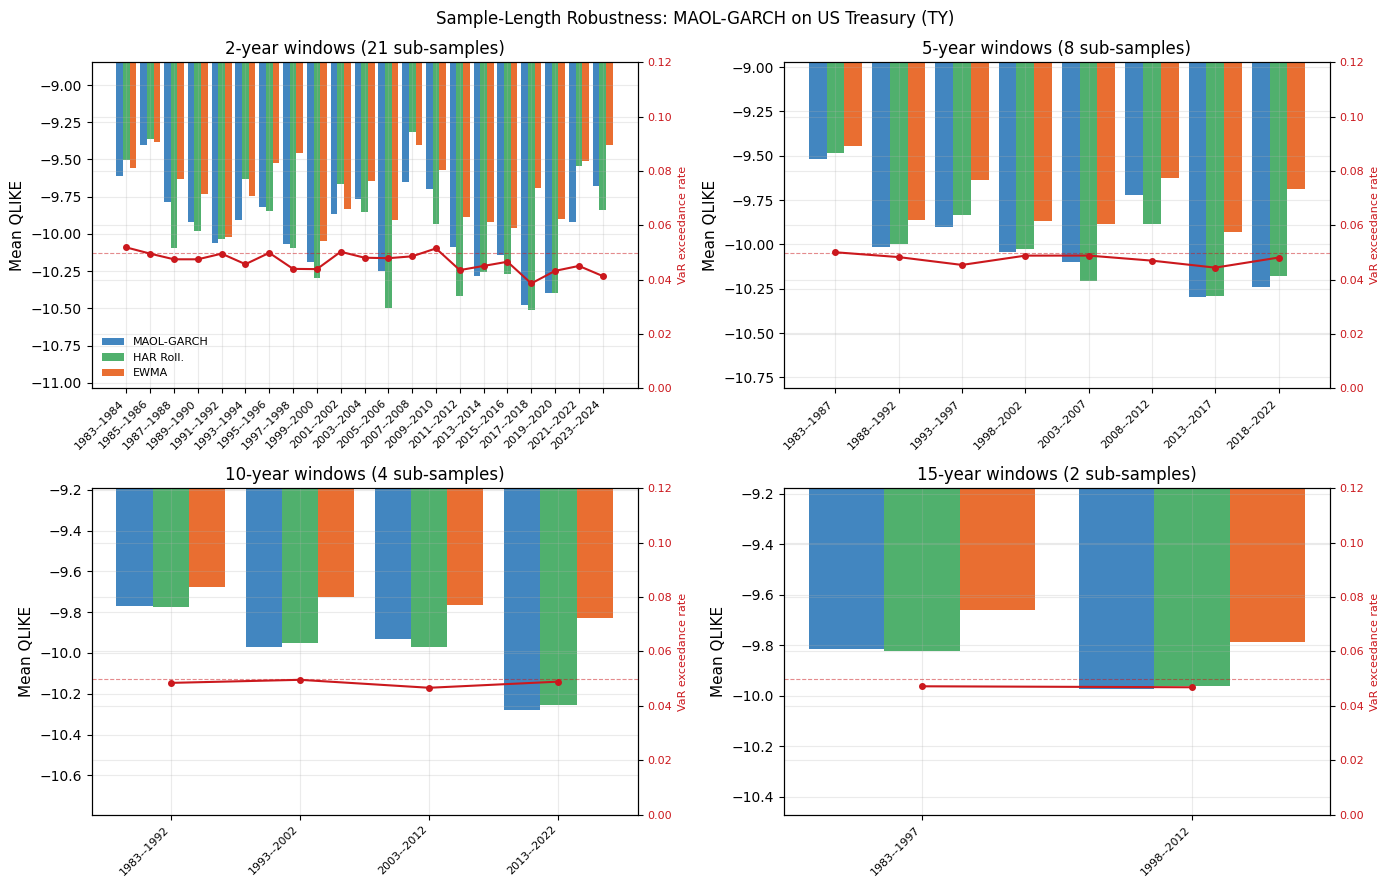

Saved: fig_sample_length.pdf


In [28]:
# ── Fig: Sample-length robustness panel ───────────────────────────────────
# Four panels (one per window length): QLIKE of MAOL vs EWMA per window,
# with R² and VaR rate as secondary series.
# Shows at a glance how performance and calibration scale with sample size.

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharey=False)
axes = axes.flatten()

for ax_i, yrs in enumerate(SAMPLE_LENGTHS):
    ax  = axes[ax_i]
    res = sl_results[yrs]
    if not res:
        ax.set_title(f"{yrs}-year windows (no data)")
        continue

    labels   = [r["window"] for r in res]
    ql_maol  = [r["ql_maol"]  for r in res]
    ql_ewma  = [r["ql_ewma"]  for r in res]
    ql_roll  = [r["ql_roll"]  for r in res]
    r2_vals  = [r["r2"]       for r in res]
    viol     = [r["viol_rate"] for r in res]
    x        = np.arange(len(labels))
    w        = 0.28

    ax.bar(x - w,   ql_maol,  w, label="MAOL-GARCH", color=C_BLUE,   alpha=0.85)
    ax.bar(x,       ql_roll,  w, label="HAR Roll.",   color=C_GREEN,  alpha=0.85)
    ax.bar(x + w,   ql_ewma,  w, label="EWMA",        color=C_ORANGE, alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
    ax.set_title(f"{yrs}-year windows ({len(res)} sub-samples)")
    ax.set_ylabel("Mean QLIKE")
    if ax_i == 0:
        ax.legend(fontsize=8, frameon=False)
    shade_min = min(ql_maol + ql_ewma + ql_roll)
    shade_max = max(ql_maol + ql_ewma + ql_roll)
    ax.set_ylim(shade_min - 0.05 * abs(shade_min), shade_max + 0.05 * abs(shade_max))

    # Secondary axis: VaR rate
    ax2 = ax.twinx()
    ax2.plot(x, viol, color=C_RED, lw=1.5, marker="o", ms=4, label="VaR rate")
    ax2.axhline(0.05, color=C_RED, ls="--", lw=0.8, alpha=0.5)
    ax2.set_ylabel("VaR exceedance rate", color=C_RED, fontsize=8)
    ax2.tick_params(axis="y", labelcolor=C_RED, labelsize=8)
    ax2.set_ylim(0.0, 0.12)

fig.suptitle("Sample-Length Robustness: MAOL-GARCH on US Treasury (TY)", fontsize=12)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig_sample_length.pdf", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: fig_sample_length.pdf")


## 14. Regime Analysis
Compares MAOL multiplier behaviour and per-step QLIKE improvement
during high-volatility regimes (GFC 2008-09, COVID 2020) vs tranquil periods.



Regime                 Obs   Mult mean   Mult max   QLIKE diff   % days MAOL wins
GFC (2008-09)          388      1.0089     1.0279     -0.02003             44.6%
COVID (2020)           103      0.9853     0.9869     +0.57408             50.5%
Tranquil             10966      1.0121     1.1339     +0.00385             49.1%


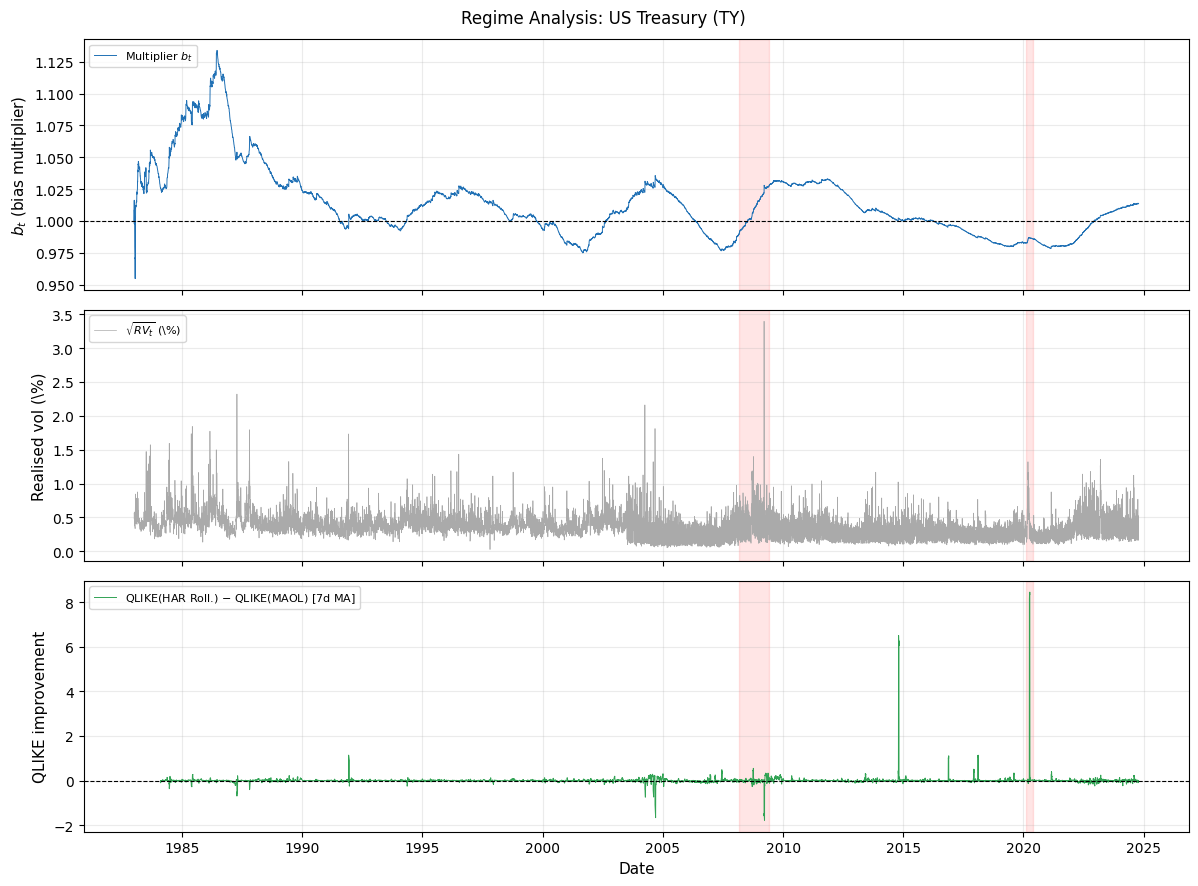

Regime figure saved.


In [30]:
# ── Regime analysis: multiplier and per-step loss in stress vs calm ────────
# Regimes defined by crisis shading already used throughout the paper.
# We add a third 'Other' category for all non-crisis observations.

REGIMES = {
    "GFC (2008-09)":    ("2008-03-01", "2009-06-01"),
    "COVID (2020)":     ("2020-02-01", "2020-06-01"),
}

hist_ty  = ty["hist"]          # MAOL-GARCH history for TY
idx_ty   = hist_ty.index
ret_ty   = ty["ret"]
rv_ty    = ty["rv"]

# Per-step QLIKE differential: MAOL vs HAR rolling (positive = HAR wins)
f_roll_ty  = fit_rolling_har(rv_ty)
ql_maol_ty = qlike_series(rv_ty, hist_ty["vhat"].values)
ql_roll_ty = qlike_series(rv_ty, f_roll_ty)
ql_diff_ty = ql_roll_ty - ql_maol_ty   # positive = MAOL better

multiplier_ty = hist_ty["multiplier"].values

def _regime_mask(idx, start, end):
    return (idx >= pd.Timestamp(start)) & (idx <= pd.Timestamp(end))

crisis_mask = np.zeros(len(idx_ty), dtype=bool)
for s, e in REGIMES.values():
    crisis_mask |= _regime_mask(idx_ty, s, e)
calm_mask = ~crisis_mask

# Summary stats by regime
regime_stats = []
for name, (s, e) in REGIMES.items():
    m = _regime_mask(idx_ty, s, e)
    valid = m & np.isfinite(multiplier_ty) & np.isfinite(ql_diff_ty)
    regime_stats.append({
        "regime": name,
        "obs":    int(valid.sum()),
        "mult_mean": float(np.mean(multiplier_ty[valid])),
        "mult_max":  float(np.max(multiplier_ty[valid])),
        "ql_diff_mean": float(np.nanmean(ql_diff_ty[valid])),   # positive = MAOL better
        "ql_diff_pct_pos": float(np.mean(ql_diff_ty[valid] > 0)),
    })

calm_valid = calm_mask & np.isfinite(multiplier_ty) & np.isfinite(ql_diff_ty)
regime_stats.append({
    "regime": "Tranquil",
    "obs":    int(calm_valid.sum()),
    "mult_mean": float(np.mean(multiplier_ty[calm_valid])),
    "mult_max":  float(np.max(multiplier_ty[calm_valid])),
    "ql_diff_mean": float(np.nanmean(ql_diff_ty[calm_valid])),
    "ql_diff_pct_pos": float(np.mean(ql_diff_ty[calm_valid] > 0)),
})

print(f"\n{'Regime':<20} {'Obs':>5}  {'Mult mean':>10}  {'Mult max':>9}  "
      f"{'QLIKE diff':>11}  {'% days MAOL wins':>17}")
for r in regime_stats:
    print(f"{r['regime']:<20} {r['obs']:>5}  {r['mult_mean']:>10.4f}  "
          f"{r['mult_max']:>9.4f}  {r['ql_diff_mean']:>+11.5f}  "
          f"{r['ql_diff_pct_pos']:>16.1%}")

# ── Figure: regime analysis panel ─────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

# Panel 1: multiplier b_t
ax = axes[0]
ax.plot(idx_ty, multiplier_ty, color=C_BLUE, lw=0.7, label="Multiplier $b_t$")
ax.axhline(1.0, color="black", lw=0.8, ls="--")
shade_crises(ax)
ax.set_ylabel("$b_t$ (bias multiplier)")
ax.legend(loc="upper left", fontsize=8)

# Panel 2: realised volatility
ax = axes[1]
ax.plot(idx_ty, np.sqrt(rv_ty) * 100, color=C_GRAY, lw=0.5, label="$\\sqrt{RV_t}$ (\\%)")
shade_crises(ax)
ax.set_ylabel("Realised vol (\\%)")
ax.legend(loc="upper left", fontsize=8)

# Panel 3: per-step QLIKE improvement (7-day rolling mean for readability)
ax = axes[2]
ql_diff_smooth = pd.Series(ql_diff_ty, index=idx_ty).rolling(7, min_periods=1).mean()
ax.plot(idx_ty, ql_diff_smooth, color=C_GREEN, lw=0.7,
        label="QLIKE(HAR Roll.) $-$ QLIKE(MAOL) [7d MA]")
ax.axhline(0.0, color="black", lw=0.8, ls="--")
shade_crises(ax)
ax.set_ylabel("QLIKE improvement")
ax.set_xlabel("Date")
ax.legend(loc="upper left", fontsize=8)

fig.suptitle("Regime Analysis: US Treasury (TY)", fontsize=12)
fig.tight_layout()
fig.savefig(FIG_DIR / "regime_analysis.pdf", bbox_inches="tight", dpi=150)
plt.show()
print("Regime figure saved.")


In [31]:
# ── Write regime summary table ─────────────────────────────────────────────
def write_regime_table(path, regime_stats):
    with open(path, "w") as f:
        _begin(f,
            caption=("Regime Analysis (US Treasury, TY). "
                     "Per-period mean of the multiplicative bias correction $b_t$, "
                     "its maximum, and the mean per-step QLIKE improvement of MAOL-GARCH "
                     "over HAR Rolling. A positive QLIKE difference indicates MAOL wins on "
                     "that day. GFC: March 2008 to June 2009. COVID: February 2020 to June 2020."),
            label="tab:regime_analysis",
            cols="lccccc", resize=False,
            header=("Regime & Obs & Mean $b_t$ & Max $b_t$ & "
                    "Mean QLIKE diff. & \\% days MAOL wins \\\\"))
        for r in regime_stats:
            f.write(f"{r['regime']} & {r['obs']:,} & "
                    f"{r['mult_mean']:.4f} & {r['mult_max']:.4f} & "
                    f"${r['ql_diff_mean']:+.5f}$ & "
                    f"{r['ql_diff_pct_pos']*100:.1f}\\% \\\\\n")
        _end(f)

write_regime_table(TAB_DIR / "tab_regime_analysis.tex", regime_stats)
print("Regime table saved.")


Regime table saved.


## 12. Figures

In [33]:
# Convenience references for the TY market
hist_df  = ty["hist"]
idx      = data["TY"].index
rv_vol   = np.sqrt(np.maximum(hist_df["rv"].values,     0))
base_vol = np.sqrt(np.maximum(hist_df["h_base"].values, 0))
adj_vol  = np.sqrt(np.maximum(hist_df["vhat"].values,   0))
returns  = hist_df["returns"].values
var_t    = hist_df["VaR"].values
pit_uncal= ty["pit_uncal"]
pit_cal  = ty["pit_cal"]
pit_skt  = ty["hist_skt"]["pit"].values
pit_skt  = pit_skt[np.isfinite(pit_skt)]
print("Figure references set.")

Figure references set.


/var/folders/cn/j57dl6552pq5z62xsmztb08w0000gp/T/ipykernel_51568/2671670707.py:28: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


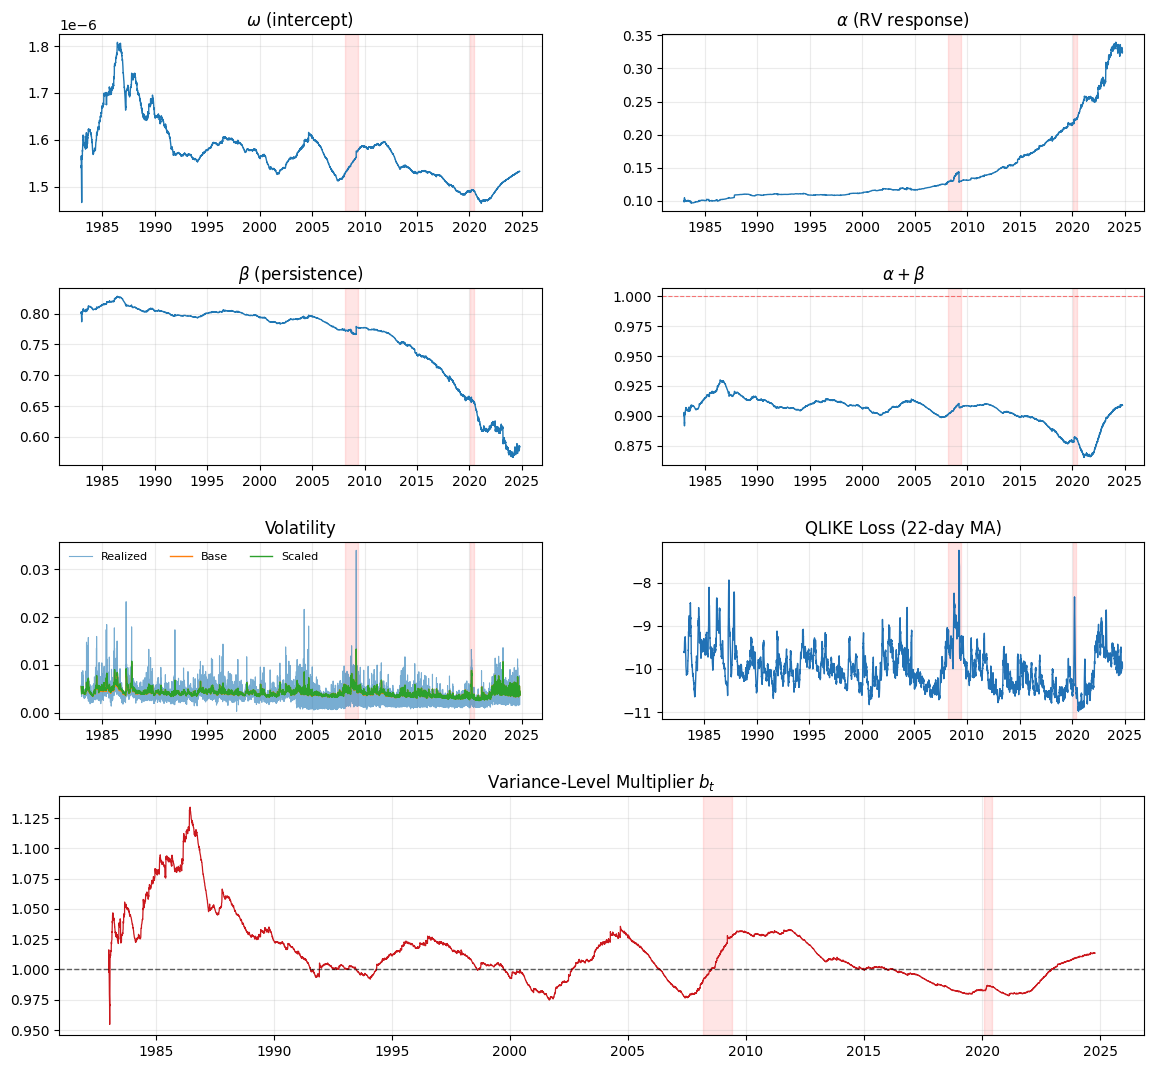

Saved: fig_parameters_over_time.pdf


In [34]:
# ── Fig 1: Parameters over time ──────────────────────────────────────────────
fig = plt.figure(figsize=(14, 13))
gs  = fig.add_gridspec(4, 2, height_ratios=[1,1,1,1.35], hspace=0.40, wspace=0.25)

panels = [("omega","$\\omega$ (intercept)"), ("alpha","$\\alpha$ (RV response)"),
          ("beta","$\\beta$ (persistence)"),  ("persistence","$\\alpha+\\beta$")]
for i,(col,title) in enumerate(panels):
    ax = fig.add_subplot(gs[i//2, i%2])
    ax.plot(idx, hist_df[col].values, lw=1.0)
    if col == "persistence": ax.axhline(1.0, color="red", ls="--", lw=0.8, alpha=0.5)
    ax.set_title(title); shade_crises(ax)

ax = fig.add_subplot(gs[2, 0])
ax.plot(idx, rv_vol, lw=0.8, alpha=0.6, label="Realized")
ax.plot(idx, base_vol, lw=1.0, label="Base"); ax.plot(idx, adj_vol, lw=1.0, label="Scaled")
ax.set_title("Volatility"); ax.legend(fontsize=8, frameon=False, ncol=3); shade_crises(ax)

ax = fig.add_subplot(gs[2, 1])
ql = np.log(np.maximum(hist_df["vhat"].values,1e-12)) + hist_df["rv"].values/np.maximum(hist_df["vhat"].values,1e-12)
ax.plot(idx, pd.Series(ql, index=idx).rolling(22).mean(), color=C_BLUE, lw=1.0)
ax.set_title("QLIKE Loss (22-day MA)"); shade_crises(ax)

ax = fig.add_subplot(gs[3, :])
ax.plot(idx, hist_df["multiplier"].values, color=C_RED, lw=0.9)
ax.axhline(1.0, color="black", ls="--", lw=1.0, alpha=0.6)
ax.set_title(r"Variance-Level Multiplier $b_t$"); shade_crises(ax)

fig.tight_layout()
fig.savefig(FIG_DIR/"fig_parameters_over_time.pdf", bbox_inches="tight")
plt.show(); print("Saved: fig_parameters_over_time.pdf")

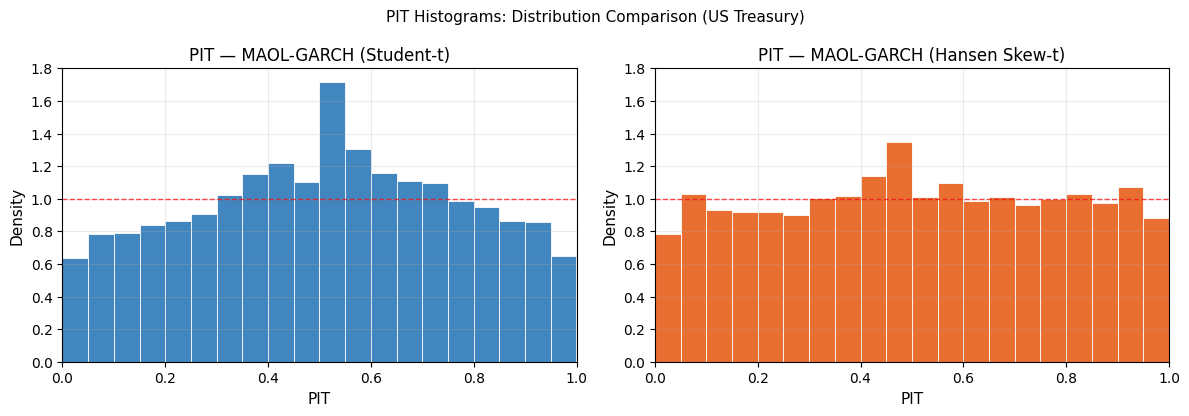

Saved: fig_pit_diagnostics.pdf


In [35]:
# ── Fig 2: PIT diagnostics — Student-t vs Hansen Skew-t ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
bins = np.linspace(0, 1, 21)
panels = [
    (axes[0], C_BLUE,   "MAOL-GARCH (Student-t)",    pit_uncal),
    (axes[1], C_ORANGE, "MAOL-GARCH (Hansen Skew-t)", pit_skt),
]
for ax, col, title, d in panels:
    ax.hist(d, bins=bins, density=True, color=col, alpha=0.85, edgecolor="white", lw=0.7)
    ax.axhline(1.0, color="red", ls="--", lw=1.0, alpha=0.7, label="Uniform")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.8)
    ax.set_title(f"PIT — {title}"); ax.set_xlabel("PIT"); ax.set_ylabel("Density")
fig.suptitle("PIT Histograms: Distribution Comparison (US Treasury)", fontsize=11)
fig.tight_layout()
fig.savefig(FIG_DIR/"fig_pit_diagnostics.pdf", bbox_inches="tight")
plt.show(); print("Saved: fig_pit_diagnostics.pdf")


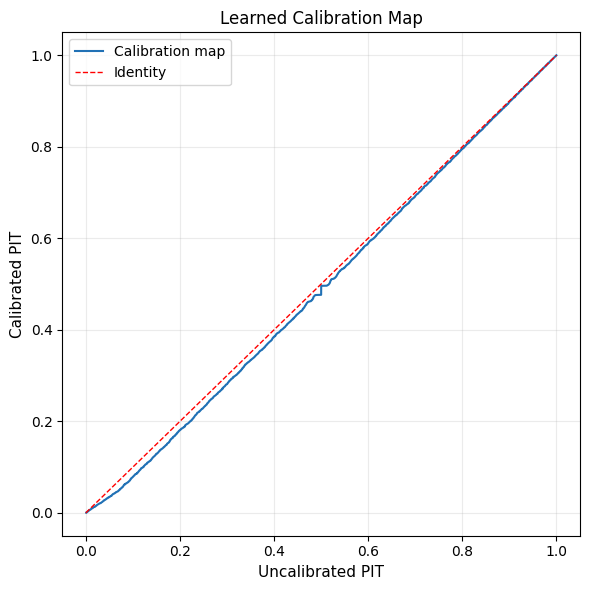

Saved: fig_calibration_map.pdf


In [36]:
# ── Fig 3: Calibration map ────────────────────────────────────────────────────
u = np.sort(pit_uncal); c = np.sort(pit_cal); n = min(len(u),len(c))
fig, ax = plt.subplots(figsize=(6,6))
ax.plot(u[:n], c[:n], color=C_BLUE, lw=1.5, label="Calibration map")
ax.plot([0,1],[0,1], "r--", lw=1.0, label="Identity")
ax.set_xlabel("Uncalibrated PIT"); ax.set_ylabel("Calibrated PIT")
ax.set_title("Learned Calibration Map"); ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR/"fig_calibration_map.pdf", bbox_inches="tight")
plt.show(); print("Saved: fig_calibration_map.pdf")

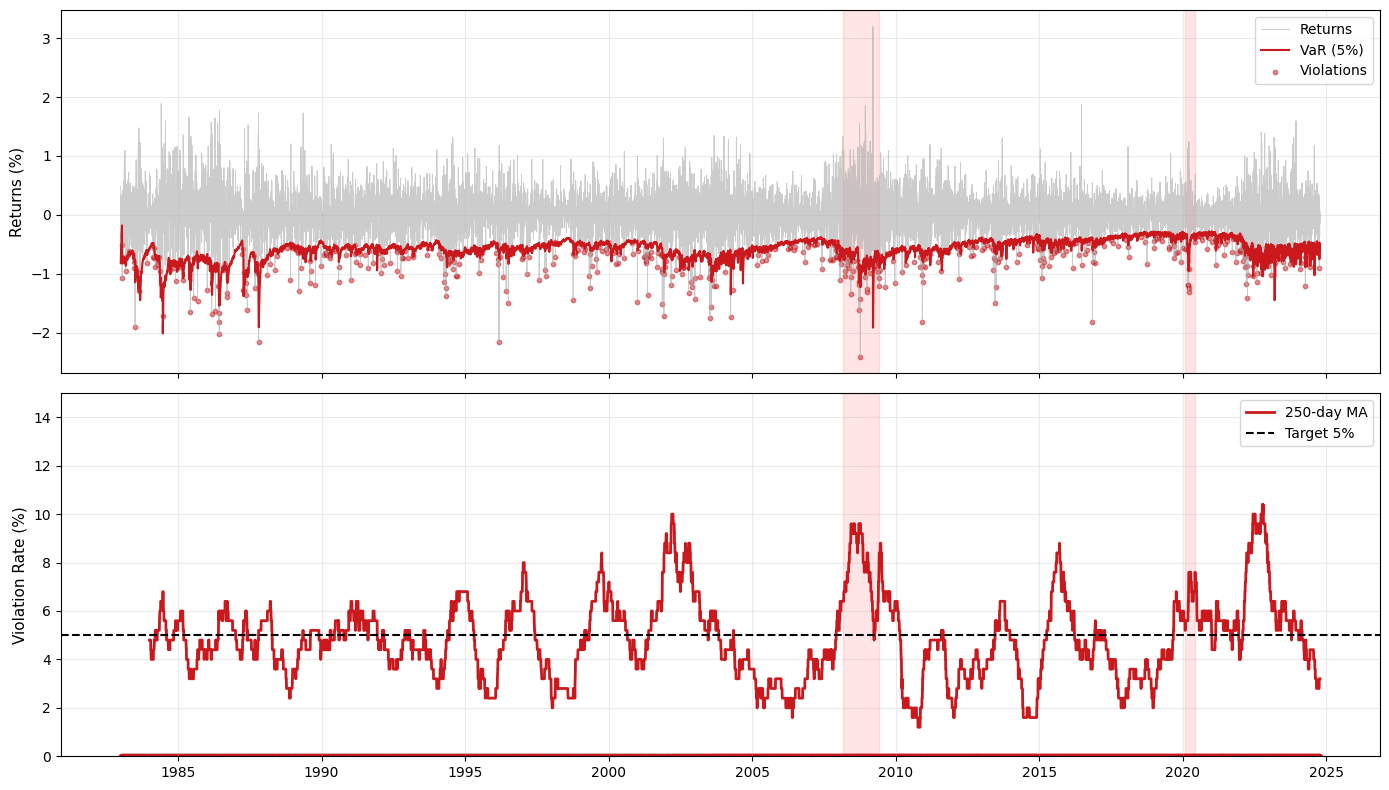

Saved: fig_var_backtest.pdf


In [37]:
# ── Fig 4: VaR backtest ───────────────────────────────────────────────────────
viol      = returns < var_t
viol_ma   = pd.Series(viol.astype(float), index=idx).rolling(250).mean()*100

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axes[0].plot(idx, returns*100, color=C_GRAY, lw=0.7, alpha=0.6, label="Returns")
axes[0].plot(idx, var_t*100,   color=C_RED,  lw=1.5, label="VaR (5%)")
axes[0].scatter(idx[viol], returns[viol]*100, color=C_RED, s=10, alpha=0.5, label="Violations")
axes[0].set_ylabel("Returns (%)"); axes[0].legend(fontsize=10); shade_crises(axes[0])

axes[1].scatter(idx, viol*100, s=8, alpha=0.2, color=C_RED)
axes[1].plot(idx, viol_ma, color=C_RED, lw=2.0, label="250-day MA")
axes[1].axhline(VAR_ALPHA*100, color="black", ls="--", lw=1.5, label="Target 5%")
axes[1].set_ylabel("Violation Rate (%)"); axes[1].set_ylim(0,15)
axes[1].legend(fontsize=10); shade_crises(axes[1])

fig.tight_layout()
fig.savefig(FIG_DIR/"fig_var_backtest.pdf", bbox_inches="tight")
plt.show(); print("Saved: fig_var_backtest.pdf")

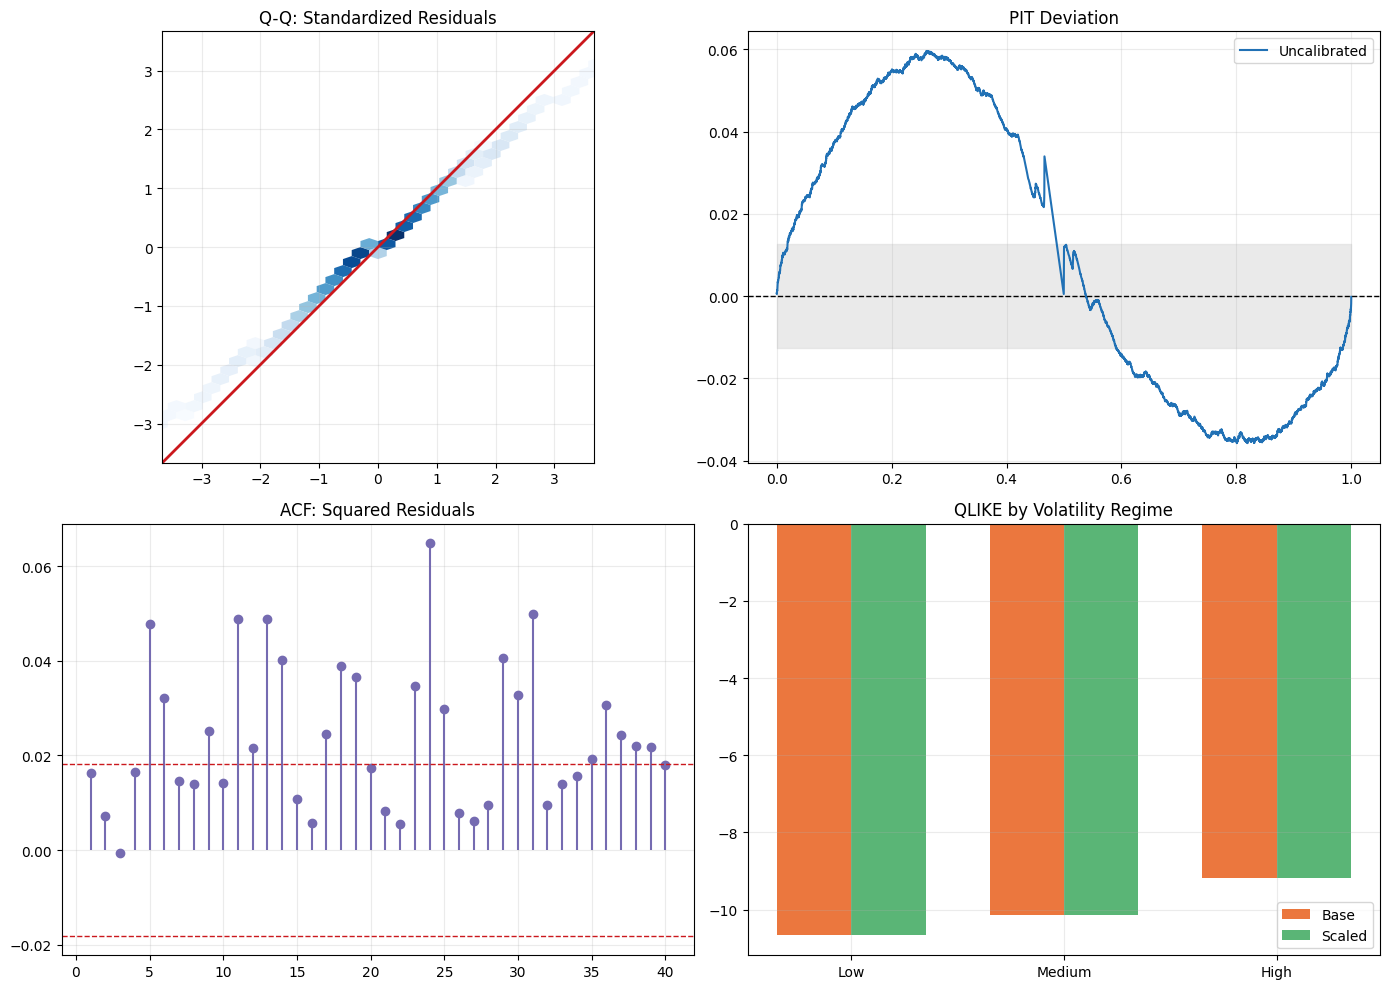

Saved: fig_diagnostics_multipanel.pdf


In [38]:
# ── Fig 5: Diagnostics multipanel ────────────────────────────────────────────
vhat_ = hist_df["vhat"].values
z     = returns / np.sqrt(np.maximum(vhat_, 1e-12))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# Q-Q
nu = float(ty["dist"].nu); s = math.sqrt((nu-2)/nu)
z_s  = np.sort(z[np.isfinite(z)] / s)
probs= (np.arange(1,len(z_s)+1) - 0.5) / len(z_s)
theo = sp_stats.t.ppf(probs, nu)
lim  = float(np.nanpercentile(np.abs(np.r_[theo, z_s]), 99))
axes[0].hexbin(theo, z_s, gridsize=80, cmap="Blues", mincnt=1, linewidths=0)
axes[0].plot([-lim,lim],[-lim,lim], color=C_RED, lw=2.0)
axes[0].set_xlim(-lim,lim); axes[0].set_ylim(-lim,lim); axes[0].set_aspect("equal")
axes[0].set_title("Q-Q: Standardized Residuals")

# PIT deviation
n_u = len(pit_uncal); tau = np.arange(1,n_u+1)/n_u
axes[1].fill_between([0,1], -1.36/math.sqrt(n_u), 1.36/math.sqrt(n_u), color="#DDD", alpha=0.6)
axes[1].plot(tau, np.sort(pit_uncal)-tau, color=C_BLUE, lw=1.5, label="Uncalibrated")
axes[1].axhline(0, color="black", ls="--", lw=1.0)
axes[1].set_title("PIT Deviation"); axes[1].legend()

# ACF of squared residuals
z2   = (z[np.isfinite(z)]**2); z2 -= z2.mean()
denom= np.dot(z2, z2); nlags = 40
acf  = [1.0]+[np.dot(z2[k:],z2[:-k])/max(denom,1e-12) for k in range(1,nlags+1)]
ml, sl, bl = axes[2].stem(range(1,nlags+1), acf[1:], basefmt=" ")
sl.set_color(C_PURPLE); ml.set_color(C_PURPLE)
conf = 1.96/math.sqrt(len(z2))
axes[2].axhline(conf, color=C_RED, ls="--", lw=1.0)
axes[2].axhline(-conf, color=C_RED, ls="--", lw=1.0)
axes[2].set_title("ACF: Squared Residuals")

# Regime QLIKE
rv_v = hist_df["rv"].values; h_b = hist_df["h_base"].values
qlo, qhi = np.nanquantile(rv_v, [0.33, 0.66])
reg = np.where(rv_v<=qlo,"Low",np.where(rv_v<=qhi,"Medium","High"))
df_r = pd.DataFrame({"regime":reg, "base": np.log(np.maximum(h_b,1e-12))+rv_v/np.maximum(h_b,1e-12),
                     "scaled":np.log(np.maximum(vhat_,1e-12))+rv_v/np.maximum(vhat_,1e-12)})
rs = df_r.groupby("regime")[["base","scaled"]].mean().reindex(["Low","Medium","High"])
x = np.arange(3); w = 0.35
axes[3].bar(x-w/2, rs["base"],   w, label="Base",   color=C_ORANGE, alpha=0.8)
axes[3].bar(x+w/2, rs["scaled"], w, label="Scaled", color=C_GREEN,  alpha=0.8)
axes[3].set_xticks(x); axes[3].set_xticklabels(["Low","Medium","High"])
axes[3].set_title("QLIKE by Volatility Regime"); axes[3].legend()

fig.tight_layout()
fig.savefig(FIG_DIR/"fig_diagnostics_multipanel.pdf", bbox_inches="tight")
plt.show(); print("Saved: fig_diagnostics_multipanel.pdf")

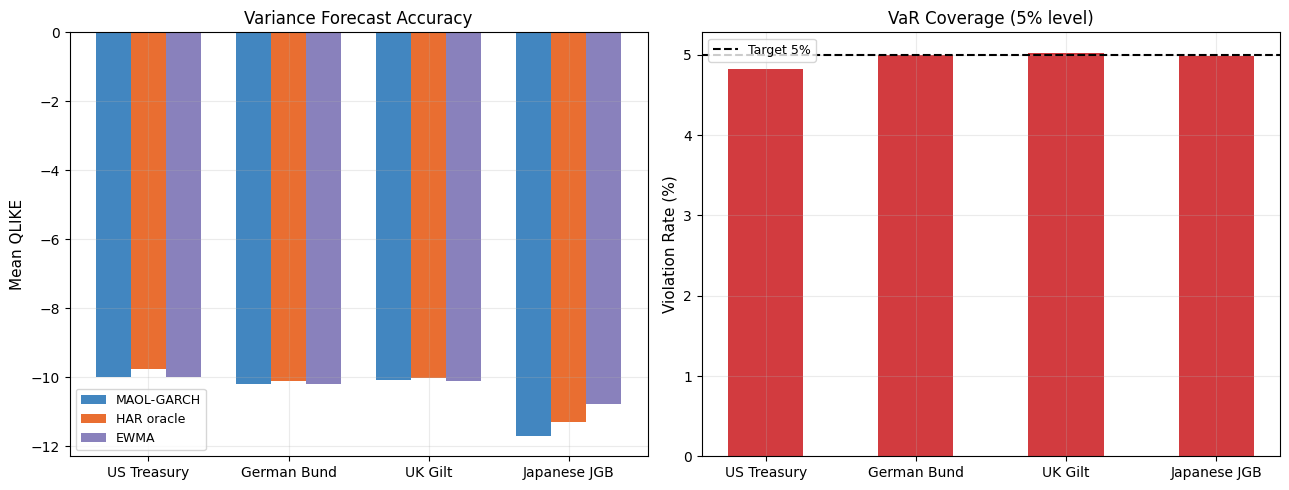

Saved: fig_cross_country_comparison.pdf


In [39]:
# ── Fig 6: Cross-country comparison ──────────────────────────────────────────
markets = [LABELS[c] for c in ORDER]
x = np.arange(len(markets)); w = 0.25

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].bar(x-w, [cc[c]["rows"][0]["qlike"] for c in ORDER], w, label="MAOL-GARCH", color=C_BLUE,   alpha=0.85)
axes[0].bar(x,   [cc[c]["rows"][7]["qlike"] for c in ORDER], w, label="HAR oracle", color=C_ORANGE, alpha=0.85)
axes[0].bar(x+w, [cc[c]["rows"][5]["qlike"] for c in ORDER], w, label="EWMA",       color=C_PURPLE, alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(markets)
axes[0].set_ylabel("Mean QLIKE"); axes[0].set_title("Variance Forecast Accuracy")
axes[0].legend(fontsize=9)

viol_rates = [cc[c]["viol_rate"]*100 for c in ORDER]
axes[1].bar(x, viol_rates, width=0.5, color=C_RED, alpha=0.85)
axes[1].axhline(5.0, color="black", ls="--", lw=1.5, label="Target 5%")
axes[1].set_xticks(x); axes[1].set_xticklabels(markets)
axes[1].set_ylabel("Violation Rate (%)"); axes[1].set_title("VaR Coverage (5% level)")
axes[1].legend(fontsize=9)

fig.tight_layout()
fig.savefig(FIG_DIR/"fig_cross_country_comparison.pdf", bbox_inches="tight")
plt.show(); print("Saved: fig_cross_country_comparison.pdf")

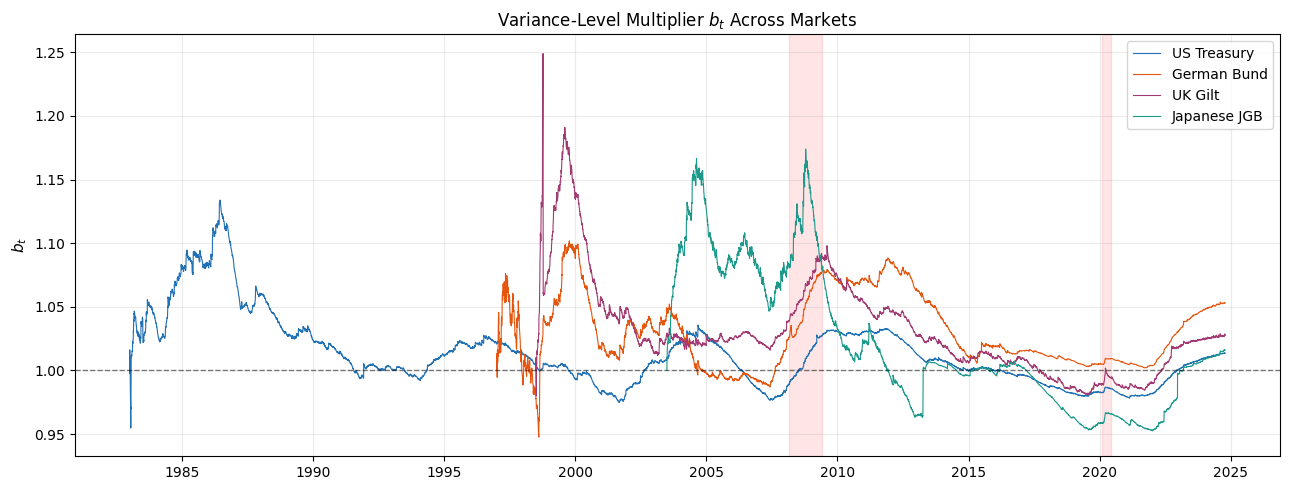

Saved: fig_multiplier_comparison.pdf


In [40]:
# ── Fig 7: Multiplier across markets ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))
for code in ORDER:
    h = cc[code]["hist"]
    ax.plot(h.index, h["multiplier"].values, lw=0.8, label=LABELS[code], color=MCOLORS[code])
ax.axhline(1.0, color="black", ls="--", lw=1.0, alpha=0.5)
shade_crises(ax)
ax.set_ylabel(r"$b_t$")
ax.set_title(r"Variance-Level Multiplier $b_t$ Across Markets")
ax.legend(fontsize=10)
fig.tight_layout()
fig.savefig(FIG_DIR/"fig_multiplier_comparison.pdf", bbox_inches="tight")
plt.show(); print("Saved: fig_multiplier_comparison.pdf")

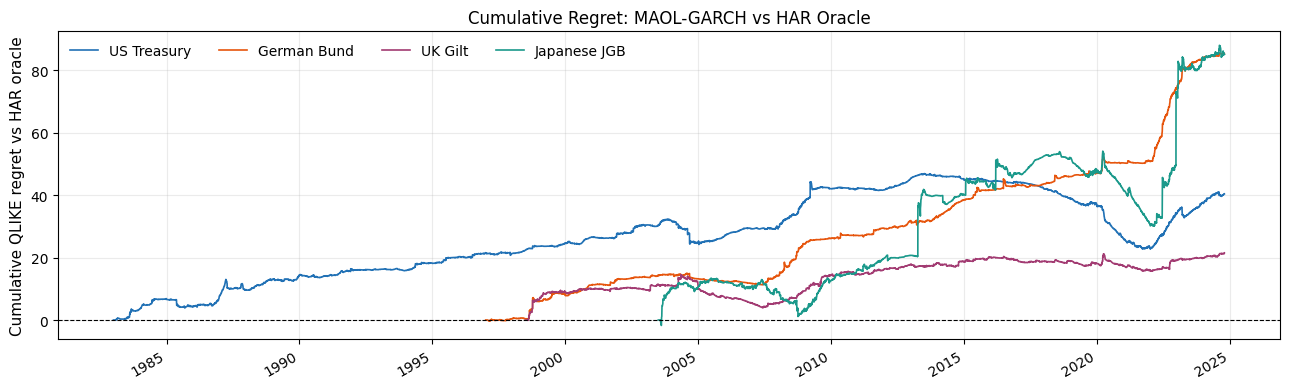

Saved: fig_cumulative_regret.pdf


In [41]:
# ── Fig 8: Cumulative regret ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 4))
for code in ORDER:
    ax.plot(data[code].index, cc[code]["cum_regret"], lw=1.2, label=LABELS[code], color=MCOLORS[code])
ax.axhline(0, color="black", lw=0.8, ls="--")
ax.set_ylabel("Cumulative QLIKE regret vs HAR oracle")
ax.set_title("Cumulative Regret: MAOL-GARCH vs HAR Oracle")
ax.legend(frameon=False, ncol=4)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator(5))
fig.autofmt_xdate(); fig.tight_layout()
fig.savefig(FIG_DIR/"fig_cumulative_regret.pdf", bbox_inches="tight")
plt.show(); print("Saved: fig_cumulative_regret.pdf")